# 03 · QAOA ideal y Guppy local

Flujo consolidado para G6/G8/G10/G12 y profundidades p=1,2,3:
optimización con múltiples reinicios, simulación de 30 repeticiones de
512 tiros, validación Guppy local y exportación de resultados. La ejecución
remota se separó en el notebook 04.

### importaciones y configuración

### Entorno de ejecución en Nexus

Este notebook utiliza directamente las versiones de `guppylang`, `qnexus` y
Selene disponibles en la plataforma Nexus. Para la ejecución con Selene no se
requiere instalar `hugr-qir` ni convertir el programa a QIR: Nexus recibe
directamente el HUGR producido por Guppy.

In [1]:
from pathlib import Path
from itertools import product

import json
import time
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 2026
TAMANOS = [6, 8, 10, 12]

np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.precision", 6)

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


### localizar la raíz del proyecto

In [2]:
DIRECTORIO_ACTUAL = Path.cwd().resolve()

candidatos_root = [
    DIRECTORIO_ACTUAL,
    DIRECTORIO_ACTUAL.parent,
]

ROOT = None

for candidato in candidatos_root:
    if (
        (candidato / "resultados" / "clasicos").exists()
        and (candidato / "datos").exists()
    ):
        ROOT = candidato
        break

if ROOT is None:
    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. "
        "Debe contener las carpetas 'datos' y "
        "'resultados/clasicos'."
    )

RESULTADOS_CLASICOS = ROOT / "resultados" / "clasicos"
RESULTADOS_QAOA = ROOT / "resultados" / "qaoa_local"
FIGURAS = ROOT / "figuras"

RESULTADOS_QAOA.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", ROOT)
print("Resultados clásicos:", RESULTADOS_CLASICOS)
print("Resultados QAOA:", RESULTADOS_QAOA)


Raíz del proyecto: /home/jovyan/reto1_qaoa_noir
Resultados clásicos: /home/jovyan/reto1_qaoa_noir/resultados/clasicos
Resultados QAOA: /home/jovyan/reto1_qaoa_noir/resultados/qaoa_local


### inventario de archivos de grafos

In [3]:
# Inventario robusto de archivos asociados con los grafos

carpetas_busqueda = [
    ROOT / "datos",
    ROOT / "datos_procesados",
]

carpetas_busqueda = [
    carpeta
    for carpeta in carpetas_busqueda
    if carpeta.exists()
]

assert carpetas_busqueda, (
    "No se encontró ninguna carpeta de datos."
)


# Formatos posibles para almacenar grafos, nodos o aristas
extensiones_datos = {
    ".graphml",
    ".gml",
    ".gpickle",
    ".pickle",
    ".pkl",
    ".json",
    ".geojson",
    ".csv",
    ".parquet",
    ".feather",
    ".edgelist",
}

palabras_clave = {
    "grafo",
    "grafos",
    "graph",
    "g6",
    "g8",
    "g10",
    "g12",
    "nodo",
    "nodos",
    "node",
    "nodes",
    "arista",
    "aristas",
    "edge",
    "edges",
}


# Obtener todos los archivos de datos estructurados
todos_archivos_datos = sorted([
    ruta
    for carpeta in carpetas_busqueda
    for ruta in carpeta.rglob("*")
    if (
        ruta.is_file()
        and ruta.suffix.lower() in extensiones_datos
    )
])


# Seleccionar candidatos según nombre, carpeta o formato nativo
extensiones_nativas_grafo = {
    ".graphml",
    ".gml",
    ".gpickle",
    ".pickle",
    ".pkl",
    ".edgelist",
}

archivos_grafo = []

for ruta in todos_archivos_datos:
    ruta_texto = str(
        ruta.relative_to(ROOT)
    ).lower()

    es_formato_nativo = (
        ruta.suffix.lower()
        in extensiones_nativas_grafo
    )

    tiene_palabra_clave = any(
        palabra in ruta_texto
        for palabra in palabras_clave
    )

    if es_formato_nativo or tiene_palabra_clave:
        archivos_grafo.append(ruta)


# Mostrar candidatos
df_archivos_grafo = pd.DataFrame([
    {
        "indice": indice,
        "archivo": ruta.name,
        "ruta_relativa": str(
            ruta.relative_to(ROOT)
        ),
        "extension": ruta.suffix.lower(),
        "tamano_bytes": ruta.stat().st_size,
    }
    for indice, ruta in enumerate(archivos_grafo)
])

display(df_archivos_grafo)


# Diagnóstico si todavía no se identifican candidatos
if len(archivos_grafo) == 0:
    print(
        "No se identificaron candidatos por nombre. "
        "Se muestran todos los archivos estructurados:"
    )

    df_todos_archivos = pd.DataFrame([
        {
            "archivo": ruta.name,
            "ruta_relativa": str(
                ruta.relative_to(ROOT)
            ),
            "extension": ruta.suffix.lower(),
            "tamano_bytes": ruta.stat().st_size,
        }
        for ruta in todos_archivos_datos
    ])

    display(df_todos_archivos)

    raise FileNotFoundError(
        "No se identificaron automáticamente los "
        "archivos correspondientes a G6, G8, G10 y G12."
    )


print(
    f"Se encontraron {len(archivos_grafo)} "
    "archivos candidatos."
)


,indice,archivo,ruta_relativa,extension,tamano_bytes
0,0,grafo_10.graphml,datos/grafos/grafo_10.graphml,.graphml,16506
1,1,grafo_10_aristas.csv,datos/grafos/grafo_10_aristas.csv,.csv,3544
2,2,grafo_10_nodos.csv,datos/grafos/grafo_10_nodos.csv,.csv,2248
3,3,grafo_12.graphml,datos/grafos/grafo_12.graphml,.graphml,19501
4,4,grafo_12_aristas.csv,datos/grafos/grafo_12_aristas.csv,.csv,4314
5,5,grafo_12_nodos.csv,datos/grafos/grafo_12_nodos.csv,.csv,2682
6,6,grafo_6.graphml,datos/grafos/grafo_6.graphml,.graphml,10543
7,7,grafo_6_aristas.csv,datos/grafos/grafo_6_aristas.csv,.csv,2064
8,8,grafo_6_nodos.csv,datos/grafos/grafo_6_nodos.csv,.csv,1418
9,9,grafo_8.graphml,datos/grafos/grafo_8.graphml,.graphml,13440


Se encontraron 12 archivos candidatos.


### cargar los resultados clásicos

In [4]:
# Inspeccionar los GraphML reales y buscar las instancias G6–G12

archivos_graphml = sorted([
    ruta
    for ruta in ROOT.rglob("*.graphml")
    if ".ipynb_checkpoints" not in ruta.parts
])

filas_inspeccion = []
grafos_graphml = {}

for ruta in archivos_graphml:
    G = nx.read_graphml(ruta)

    # Trabajar como grafo simple no dirigido
    if G.is_directed():
        G = G.to_undirected()

    # Convertir los pesos leídos desde GraphML a float
    for u, v, datos in G.edges(data=True):
        datos["weight"] = float(
            datos.get("weight", datos.get("peso", 1.0))
        )

    grafos_graphml[ruta] = G

    filas_inspeccion.append({
        "archivo": ruta.name,
        "ruta_relativa": str(ruta.relative_to(ROOT)),
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "conectado": (
            nx.is_connected(G)
            if G.number_of_nodes() > 0
            else False
        ),
        "bipartito": nx.is_bipartite(G),
        "peso_total": sum(
            datos["weight"]
            for _, _, datos in G.edges(data=True)
        ),
    })

df_inspeccion_grafos = pd.DataFrame(
    filas_inspeccion
).sort_values(
    ["nodos", "archivo"]
).reset_index(drop=True)

display(df_inspeccion_grafos)

tamanos_encontrados = set(
    df_inspeccion_grafos["nodos"].astype(int)
)

faltantes = [
    n for n in TAMANOS
    if n not in tamanos_encontrados
]

if faltantes:
    print(
        "No existen GraphML independientes para:",
        [f"G{n}" for n in faltantes],
    )
    print(
        "Será necesario reconstruirlos con el mismo "
        "procedimiento usado en el notebook clásico."
    )
else:
    print(
        "Se encontraron archivos compatibles con "
        "todos los tamaños G6, G8, G10 y G12."
    )

,archivo,ruta_relativa,nodos,aristas,conectado,bipartito,peso_total
0,grafo_6.graphml,datos/grafos/grafo_6.graphml,6,5,True,True,38.301790
1,grafo_6.graphml,resultados/grafo_6.graphml,6,5,True,True,38.301790
2,grafo_8.graphml,datos/grafos/grafo_8.graphml,8,7,True,True,42.218037
3,grafo_8.graphml,resultados/grafo_8.graphml,8,7,True,True,42.218037
4,grafo_10.graphml,datos/grafos/grafo_10.graphml,10,9,True,True,87.075048
5,grafo_10.graphml,resultados/grafo_10.graphml,10,9,True,True,87.075048
6,grafo_12.graphml,datos/grafos/grafo_12.graphml,12,11,True,True,93.299621
7,grafo_12.graphml,resultados/grafo_12.graphml,12,11,True,True,93.299621


Se encontraron archivos compatibles con todos los tamaños G6, G8, G10 y G12.


In [5]:
ruta_baseline = (
    RESULTADOS_CLASICOS
    / "baseline_clasico_completo.csv"
)

assert ruta_baseline.exists(), (
    "No se encontró baseline_clasico_completo.csv."
)

df_baseline = pd.read_csv(ruta_baseline)

columnas_requeridas = {
    "n",
    "metodo",
    "media",
    "mejor",
    "optimo_exacto",
    "razon_media",
}

faltantes = columnas_requeridas - set(df_baseline.columns)

assert not faltantes, (
    f"Faltan columnas en el baseline: {sorted(faltantes)}"
)

df_exactos_referencia = (
    df_baseline[
        df_baseline["metodo"] == "Exacto"
    ][
        [
            "n",
            "optimo_exacto",
            "mejor",
        ]
    ]
    .sort_values("n")
    .reset_index(drop=True)
)

assert set(df_exactos_referencia["n"]) == set(TAMANOS), (
    "El baseline no contiene los cuatro grafos esperados."
)

OPTIMOS_EXACTOS = dict(zip(
    df_exactos_referencia["n"].astype(int),
    df_exactos_referencia["optimo_exacto"].astype(float),
))

display(df_exactos_referencia)

print("Óptimos exactos cargados:")
for n in TAMANOS:
    print(f"  G{n}: {OPTIMOS_EXACTOS[n]:.6f}")

,n,optimo_exacto,mejor
0,6,38.301790,38.301790
1,8,42.218037,42.218037
2,10,87.075048,87.075048
3,12,93.299621,93.299621


Óptimos exactos cargados:
  G6: 38.301790
  G8: 42.218037
  G10: 87.075048
  G12: 93.299621


### cargar las cuatro instancias definitivas

In [6]:
RUTAS_GRAFOS = {
    n: ROOT / "datos" / "grafos" / f"grafo_{n}.graphml"
    for n in TAMANOS
}

grafos = {}
orden_nodos = {}
filas_validacion = []

for n, ruta in RUTAS_GRAFOS.items():
    assert ruta.exists(), (
        f"No se encontró el archivo de G{n}: {ruta}"
    )

    G_original = nx.read_graphml(ruta)

    assert not G_original.is_directed(), (
        f"G{n} no debe ser dirigido."
    )

    assert not G_original.is_multigraph(), (
        f"G{n} contiene aristas múltiples."
    )

    # Reconstruir como grafo simple con pesos float
    G = nx.Graph()
    G.add_nodes_from(G_original.nodes(data=True))

    for u, v, datos in G_original.edges(data=True):
        peso = datos.get(
            "weight",
            datos.get("peso", 1.0),
        )

        peso = float(peso)

        assert np.isfinite(peso), (
            f"G{n} contiene un peso no finito."
        )

        assert peso > 0, (
            f"G{n} contiene un peso no positivo."
        )

        G.add_edge(u, v, weight=peso)

    assert G.number_of_nodes() == n, (
        f"G{n} tiene {G.number_of_nodes()} nodos."
    )

    assert nx.is_connected(G), (
        f"G{n} no es conectado."
    )

    peso_total = sum(
        datos["weight"]
        for _, _, datos in G.edges(data=True)
    )

    assert np.isclose(
        peso_total,
        OPTIMOS_EXACTOS[n],
        atol=1e-6,
    ), (
        f"El peso de G{n} no coincide con el óptimo exacto."
    )

    grafos[n] = G
    orden_nodos[n] = sorted(
        G.nodes(),
        key=lambda nodo: str(nodo),
    )

    filas_validacion.append({
        "n": n,
        "archivo": ruta.name,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "conectado": nx.is_connected(G),
        "bipartito": nx.is_bipartite(G),
        "peso_total": peso_total,
        "optimo_exacto": OPTIMOS_EXACTOS[n],
        "diferencia": (
            peso_total - OPTIMOS_EXACTOS[n]
        ),
    })

df_validacion_qaoa = pd.DataFrame(
    filas_validacion
)

display(df_validacion_qaoa)

print("Las cuatro instancias fueron cargadas correctamente.")

,n,archivo,nodos,aristas,conectado,bipartito,peso_total,optimo_exacto,diferencia
0,6,grafo_6.graphml,6,5,True,True,38.301790,38.301790,-1.331308e-09
1,8,grafo_8.graphml,8,7,True,True,42.218037,42.218037,-1.331806e-09
2,10,grafo_10.graphml,10,9,True,True,87.075048,87.075048,-1.883123e-09
3,12,grafo_12.graphml,12,11,True,True,93.299621,93.299621,-2.067466e-09


Las cuatro instancias fueron cargadas correctamente.


## Formulación QAOA para Max-Cut

Para una arista ponderada (i,j), el operador de costo es:

$$C_{ij}=\frac{w_{ij}}{2}(I-Z_iZ_j)$$

El Hamiltoniano total de Max-Cut es:

$$H_C=\sum_{(i,j)\in E}\frac{w_{ij}}{2}(I-Z_iZ_j)$$

El Hamiltoniano mezclador es:

$$H_B=\sum_{i=1}^{n}X_i$$

Para profundidad p, el estado QAOA se construye como:

$$|\gamma,\beta\rangle =\prod_{\ell=1}^{p}e^{-i\beta_\ell H_B}e^{-i\gamma_\ell H_C}|+\rangle^{\otimes n}$$
El optimizador clásico busca maximizar:

$$\langle H_C\rangle =\langle\gamma,\beta|H_C|\gamma,\beta\rangle$$

### calcular el costo de todos los bitstrings

In [7]:
COSTOS = {}
BITS = {}
filas_espacio_estados = []

for n in TAMANOS:
    G = grafos[n]
    nodos = orden_nodos[n]

    posicion_nodo = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    indices = np.arange(
        2 ** n,
        dtype=np.uint64,
    )

    bits = (
        (
            indices[:, None]
            >> np.arange(n, dtype=np.uint64)
        )
        & 1
    ).astype(np.int8)

    costos = np.zeros(
        2 ** n,
        dtype=float,
    )

    for u, v, datos in G.edges(data=True):
        i = posicion_nodo[u]
        j = posicion_nodo[v]
        peso = float(datos["weight"])

        costos += peso * (
            bits[:, i] != bits[:, j]
        )

    BITS[n] = bits
    COSTOS[n] = costos

    costo_maximo = float(costos.max())

    mascara_optima = np.isclose(
        costos,
        costo_maximo,
        atol=1e-8,
    )

    assert np.isclose(
        costo_maximo,
        OPTIMOS_EXACTOS[n],
        atol=1e-6,
    ), (
        f"El costo máximo calculado de G{n} "
        "no coincide con el óptimo."
    )

    filas_espacio_estados.append({
        "n": n,
        "estados": 2 ** n,
        "costo_minimo": float(costos.min()),
        "costo_medio": float(costos.mean()),
        "costo_maximo": costo_maximo,
        "bitstrings_optimos": int(
            mascara_optima.sum()
        ),
    })

df_espacio_estados = pd.DataFrame(
    filas_espacio_estados
)

display(df_espacio_estados)

print("Funciones de costo verificadas correctamente.")

,n,estados,costo_minimo,costo_medio,costo_maximo,bitstrings_optimos
0,6,64,0.0,19.150895,38.301790,2
1,8,256,0.0,21.109019,42.218037,2
2,10,1024,0.0,43.537524,87.075048,2
3,12,4096,0.0,46.649811,93.299621,2


Funciones de costo verificadas correctamente.


### simulador QAOA por vector de estado

In [8]:
def aplicar_mezclador(
    estado,
    beta,
    n,
):
    """
    Aplica exp(-i * beta * sum_i X_i).
    """
    resultado = estado.copy()

    coseno = np.cos(beta)
    seno = np.sin(beta)

    indices = np.arange(
        len(resultado),
        dtype=np.uint64,
    )

    for qubit in range(n):
        mascara = np.uint64(1 << qubit)

        indices_cero = indices[
            (indices & mascara) == 0
        ]

        indices_uno = (
            indices_cero | mascara
        )

        amplitudes_cero = resultado[
            indices_cero
        ].copy()

        amplitudes_uno = resultado[
            indices_uno
        ].copy()

        resultado[indices_cero] = (
            coseno * amplitudes_cero
            - 1j * seno * amplitudes_uno
        )

        resultado[indices_uno] = (
            -1j * seno * amplitudes_cero
            + coseno * amplitudes_uno
        )

    return resultado


def simular_qaoa(
    n,
    gammas,
    betas,
):
    """
    Construye el estado QAOA para el grafo Gn.
    """
    gammas = np.asarray(
        gammas,
        dtype=float,
    )

    betas = np.asarray(
        betas,
        dtype=float,
    )

    assert gammas.ndim == 1
    assert betas.ndim == 1

    assert len(gammas) == len(betas), (
        "Debe existir un gamma y un beta por capa."
    )

    estado = np.ones(
        2 ** n,
        dtype=complex,
    ) / np.sqrt(2 ** n)

    for gamma, beta in zip(gammas, betas):
        # Operador de costo
        estado *= np.exp(
            -1j * gamma * COSTOS[n]
        )

        # Operador mezclador
        estado = aplicar_mezclador(
            estado,
            beta,
            n,
        )

    return estado


def metricas_estado_qaoa(
    n,
    estado,
):
    probabilidades = np.abs(estado) ** 2
    costos = COSTOS[n]
    optimo = OPTIMOS_EXACTOS[n]

    esperanza = float(
        probabilidades @ costos
    )

    mascara_optima = np.isclose(
        costos,
        optimo,
        atol=1e-8,
    )

    probabilidad_optimo = float(
        probabilidades[mascara_optima].sum()
    )

    indice_mas_probable = int(
        np.argmax(probabilidades)
    )

    bitstring_mas_probable = "".join(
        str(int(bit))
        for bit in BITS[n][indice_mas_probable]
    )

    return {
        "esperanza": esperanza,
        "razon_esperada": esperanza / optimo,
        "probabilidad_optimo": probabilidad_optimo,
        "bitstring_mas_probable":
            bitstring_mas_probable,
        "costo_bitstring_mas_probable": float(
            costos[indice_mas_probable]
        ),
        "probabilidad_mas_alta": float(
            probabilidades[indice_mas_probable]
        ),
        "norma": float(
            probabilidades.sum()
        ),
    }

### pruebas de consistencia del simulador

In [9]:
filas_prueba = []

for n in TAMANOS:
    # Estado |+> antes de aplicar QAOA
    estado_inicial = np.ones(
        2 ** n,
        dtype=complex,
    ) / np.sqrt(2 ** n)

    esperanza_inicial = float(
        np.abs(estado_inicial) ** 2
        @ COSTOS[n]
    )

    peso_total = sum(
        datos["weight"]
        for _, _, datos
        in grafos[n].edges(data=True)
    )

    esperanza_teorica = peso_total / 2.0

    # Prueba unitaria con parámetros arbitrarios
    estado_prueba = simular_qaoa(
        n=n,
        gammas=[0.4],
        betas=[0.3],
    )

    metricas = metricas_estado_qaoa(
        n,
        estado_prueba,
    )

    assert np.isclose(
        esperanza_inicial,
        esperanza_teorica,
        atol=1e-8,
    ), (
        f"El estado inicial de G{n} no coincide "
        "con el control aleatorio."
    )

    assert np.isclose(
        metricas["norma"],
        1.0,
        atol=1e-10,
    ), (
        f"El circuito de G{n} no conserva la norma."
    )

    filas_prueba.append({
        "n": n,
        "esperanza_inicial": esperanza_inicial,
        "esperanza_teorica": esperanza_teorica,
        "error_inicial": (
            esperanza_inicial
            - esperanza_teorica
        ),
        "norma_qaoa_prueba": metricas["norma"],
        "razon_qaoa_prueba":
            metricas["razon_esperada"],
        "probabilidad_optimo_prueba":
            metricas["probabilidad_optimo"],
    })

df_pruebas_qaoa = pd.DataFrame(
    filas_prueba
)

display(df_pruebas_qaoa)

print("Simulador QAOA validado correctamente.")

,n,esperanza_inicial,esperanza_teorica,error_inicial,norma_qaoa_prueba,razon_qaoa_prueba,probabilidad_optimo_prueba
0,6,19.150895,19.150895,0.000000e+00,1.0,0.582126,0.118799
1,8,21.109019,21.109019,0.000000e+00,1.0,0.546795,0.036548
2,10,43.537524,43.537524,-7.105427e-15,1.0,0.551327,0.005462
3,12,46.649811,46.649811,-2.131628e-14,1.0,0.561902,0.001472


Simulador QAOA validado correctamente.


### explicación de la optimización

## Optimización de parámetros

Para facilitar la comparación entre grafos con pesos diferentes, se optimiza un
parámetro escalado:

\[
\widetilde{\gamma}_\ell
=
\gamma_\ell C_{\max}
\]

donde \(C_{\max}\) es el óptimo exacto del grafo. Por tanto, el parámetro físico
utilizado en el circuito es:

\[
\gamma_\ell
=
\frac{\widetilde{\gamma}_\ell}{C_{\max}}
\]

Este escalamiento no modifica la familia de estados QAOA; solamente mejora la
estabilidad de la búsqueda clásica.

Se realizan varios reinicios para reducir el riesgo de quedar atrapados en un
óptimo local. Para profundidades mayores se incluye como punto inicial la mejor
solución de la profundidad anterior.

### funciones de optimización

In [10]:
def objetivo_qaoa(
    parametros_escalados,
    n,
    p,
):
    """
    Devuelve la razón esperada negativa porque scipy.minimize
    realiza minimización.
    """
    parametros_escalados = np.asarray(
        parametros_escalados,
        dtype=float,
    )

    gammas_escalados = parametros_escalados[:p]
    betas = parametros_escalados[p:]

    # Convertir al gamma físico utilizado por el simulador
    gammas_fisicos = (
        gammas_escalados
        / OPTIMOS_EXACTOS[n]
    )

    estado = simular_qaoa(
        n=n,
        gammas=gammas_fisicos,
        betas=betas,
    )

    probabilidades = np.abs(estado) ** 2

    esperanza = float(
        probabilidades @ COSTOS[n]
    )

    razon = (
        esperanza
        / OPTIMOS_EXACTOS[n]
    )

    return -razon


def generar_inicios(
    n,
    p,
    cantidad,
    mejores_previos,
):
    """
    Genera puntos iniciales reproducibles.
    """
    rng = np.random.default_rng(
        SEED + 100 * n + p
    )

    limites_inferiores = np.zeros(2 * p)

    limites_superiores = np.concatenate([
        np.full(p, 2.0 * np.pi),
        np.full(p, np.pi),
    ])

    inicios = []

    if p == 1:
        # Búsqueda preliminar en una malla para p=1
        malla_gamma = np.linspace(
            0.0,
            2.0 * np.pi,
            25,
            endpoint=False,
        )

        malla_beta = np.linspace(
            0.0,
            np.pi,
            25,
            endpoint=False,
        )

        candidatos = []
        valores = []

        for gamma in malla_gamma:
            for beta in malla_beta:
                parametros = np.array(
                    [gamma, beta],
                    dtype=float,
                )

                candidatos.append(parametros)

                valores.append(
                    objetivo_qaoa(
                        parametros,
                        n,
                        p,
                    )
                )

        mejores_indices = np.argsort(
            valores
        )[:cantidad]

        inicios.extend([
            candidatos[indice].copy()
            for indice in mejores_indices
        ])

    else:
        # La última capa con gamma=beta=0 conserva
        # exactamente el estado de profundidad p-1.
        anterior = mejores_previos[
            (n, p - 1)
        ]["parametros_escalados"]

        gamma_anterior = anterior[:p - 1]
        beta_anterior = anterior[p - 1:]

        inicio_calido = np.concatenate([
            gamma_anterior,
            [0.0],
            beta_anterior,
            [0.0],
        ])

        inicios.append(inicio_calido)

        # Variaciones pequeñas del inicio cálido
        for _ in range(min(3, cantidad - 1)):
            perturbacion = rng.normal(
                loc=0.0,
                scale=0.08,
                size=2 * p,
            )

            candidato = np.clip(
                inicio_calido + perturbacion,
                limites_inferiores,
                limites_superiores,
            )

            inicios.append(candidato)

        # Completar con inicializaciones aleatorias
        while len(inicios) < cantidad:
            candidato = rng.uniform(
                low=limites_inferiores,
                high=limites_superiores,
            )

            inicios.append(candidato)

    return inicios[:cantidad]

### ejecutar la optimización

In [11]:
NUM_INICIOS = {
    1: 6,
    2: 10,
    3: 12,
}

PROFUNDIDADES = [1, 2, 3]

mejores_por_profundidad = {}
filas_optimizacion = []

inicio_total = time.perf_counter()

for n in TAMANOS:
    print(f"\nOptimizando G{n}")

    for p in PROFUNDIDADES:
        tiempo_inicio = time.perf_counter()

        limites = (
            [(0.0, 2.0 * np.pi)] * p
            + [(0.0, np.pi)] * p
        )

        inicios = generar_inicios(
            n=n,
            p=p,
            cantidad=NUM_INICIOS[p],
            mejores_previos=mejores_por_profundidad,
        )

        mejor_razon = -np.inf
        mejor_registro = None

        for reinicio, inicio in enumerate(
            inicios,
            start=1,
        ):
            razon_inicial = -objetivo_qaoa(
                inicio,
                n,
                p,
            )

            resultado = minimize(
                objetivo_qaoa,
                x0=inicio,
                args=(n, p),
                method="L-BFGS-B",
                bounds=limites,
                options={
                    "maxiter": 300,
                    "ftol": 1e-12,
                    "gtol": 1e-8,
                    "maxls": 40,
                },
            )

            # Conservar la optimización solo si mejora
            # el punto inicial y produce un valor finito.
            razon_optimizada = (
                -float(resultado.fun)
                if np.isfinite(resultado.fun)
                else -np.inf
            )

            if razon_optimizada >= razon_inicial:
                parametros_elegidos = (
                    resultado.x.copy()
                )
                fuente = "optimizado"
            else:
                parametros_elegidos = inicio.copy()
                fuente = "inicio"

            gammas_escalados = (
                parametros_elegidos[:p]
            )

            betas = parametros_elegidos[p:]

            gammas_fisicos = (
                gammas_escalados
                / OPTIMOS_EXACTOS[n]
            )

            estado = simular_qaoa(
                n=n,
                gammas=gammas_fisicos,
                betas=betas,
            )

            metricas = metricas_estado_qaoa(
                n,
                estado,
            )

            fila = {
                "n": n,
                "p": p,
                "reinicio": reinicio,
                "fuente_elegida": fuente,
                "convergencia_scipy":
                    bool(resultado.success),
                "iteraciones":
                    int(resultado.nit),
                "evaluaciones":
                    int(resultado.nfev),
                "esperanza":
                    metricas["esperanza"],
                "razon_esperada":
                    metricas["razon_esperada"],
                "probabilidad_optimo":
                    metricas["probabilidad_optimo"],
                "bitstring_mas_probable":
                    metricas["bitstring_mas_probable"],
                "costo_bitstring_mas_probable":
                    metricas[
                        "costo_bitstring_mas_probable"
                    ],
                "probabilidad_mas_alta":
                    metricas["probabilidad_mas_alta"],
                "norma":
                    metricas["norma"],
            }

            # Guardar hasta tres capas en columnas separadas
            for capa in range(1, 4):
                if capa <= p:
                    fila[
                        f"gamma_escalado_{capa}"
                    ] = gammas_escalados[capa - 1]

                    fila[
                        f"gamma_fisico_{capa}"
                    ] = gammas_fisicos[capa - 1]

                    fila[
                        f"beta_{capa}"
                    ] = betas[capa - 1]
                else:
                    fila[
                        f"gamma_escalado_{capa}"
                    ] = np.nan

                    fila[
                        f"gamma_fisico_{capa}"
                    ] = np.nan

                    fila[
                        f"beta_{capa}"
                    ] = np.nan

            filas_optimizacion.append(fila)

            if (
                metricas["razon_esperada"]
                > mejor_razon
            ):
                mejor_razon = (
                    metricas["razon_esperada"]
                )

                mejor_registro = {
                    "parametros_escalados":
                        parametros_elegidos.copy(),
                    "gammas_fisicos":
                        gammas_fisicos.copy(),
                    "betas":
                        betas.copy(),
                    "metricas":
                        metricas.copy(),
                    "reinicio":
                        reinicio,
                }

        mejores_por_profundidad[
            (n, p)
        ] = mejor_registro

        duracion = (
            time.perf_counter()
            - tiempo_inicio
        )

        print(
            f"  p={p}: "
            f"razón={mejor_razon:.6f}, "
            f"P(óptimo)="
            f"{mejor_registro['metricas']['probabilidad_optimo']:.6f}, "
            f"tiempo={duracion:.2f} s"
        )

duracion_total = (
    time.perf_counter()
    - inicio_total
)

print(
    f"\nOptimización terminada en "
    f"{duracion_total:.2f} segundos."
)


Optimizando G6
  p=1: razón=0.838432, P(óptimo)=0.157418, tiempo=0.38 s
  p=2: razón=0.878059, P(óptimo)=0.218421, tiempo=2.36 s
  p=3: razón=0.917346, P(óptimo)=0.379235, tiempo=6.48 s

Optimizando G8
  p=1: razón=0.811577, P(óptimo)=0.046878, tiempo=0.46 s
  p=2: razón=0.854904, P(óptimo)=0.076807, tiempo=1.46 s
  p=3: razón=0.894451, P(óptimo)=0.153491, tiempo=5.45 s

Optimizando G10
  p=1: razón=0.793778, P(óptimo)=0.016451, tiempo=0.97 s
  p=2: razón=0.843226, P(óptimo)=0.027111, tiempo=3.38 s
  p=3: razón=0.871222, P(óptimo)=0.042464, tiempo=8.55 s

Optimizando G12
  p=1: razón=0.780929, P(óptimo)=0.005385, tiempo=1.96 s
  p=2: razón=0.825970, P(óptimo)=0.009036, tiempo=5.79 s
  p=3: razón=0.853893, P(óptimo)=0.014891, tiempo=25.90 s

Optimización terminada en 63.15 segundos.


### resumen y validaciones

In [12]:
df_optimizacion_qaoa = pd.DataFrame(
    filas_optimizacion
)

filas_mejores = []

for n in TAMANOS:
    for p in PROFUNDIDADES:
        mejor = mejores_por_profundidad[
            (n, p)
        ]

        metricas = mejor["metricas"]
        fila = {
            "n": n,
            "p": p,
        
            # Listas completas utilizadas posteriormente por Guppy.
            "gammas_fisicos": [
                float(valor)
                for valor in mejor["gammas_fisicos"]
            ],
            "betas": [
                float(valor)
                for valor in mejor["betas"]
            ],
        
            "reinicio_mejor":
                mejor["reinicio"],
            "esperanza":
                metricas["esperanza"],
            "optimo_exacto":
                OPTIMOS_EXACTOS[n],
            "razon_esperada":
                metricas["razon_esperada"],
            "probabilidad_optimo":
                metricas["probabilidad_optimo"],
            "bitstring_mas_probable":
                metricas[
                    "bitstring_mas_probable"
                ],
            "costo_bitstring_mas_probable":
                metricas[
                    "costo_bitstring_mas_probable"
                ],
            "probabilidad_mas_alta":
                metricas[
                    "probabilidad_mas_alta"
                ],
        }

        for capa in range(1, 4):
            if capa <= p:
                fila[
                    f"gamma_fisico_{capa}"
                ] = mejor[
                    "gammas_fisicos"
                ][capa - 1]

                fila[
                    f"beta_{capa}"
                ] = mejor[
                    "betas"
                ][capa - 1]
            else:
                fila[
                    f"gamma_fisico_{capa}"
                ] = np.nan

                fila[
                    f"beta_{capa}"
                ] = np.nan

        filas_mejores.append(fila)

df_mejores_qaoa = pd.DataFrame(
    filas_mejores
).sort_values(
    ["n", "p"]
).reset_index(drop=True)


# Validaciones
assert np.isfinite(
    df_mejores_qaoa[
        [
            "esperanza",
            "razon_esperada",
            "probabilidad_optimo",
        ]
    ].to_numpy(dtype=float)
).all(), (
    "Hay resultados QAOA faltantes o infinitos."
)

assert (
    df_mejores_qaoa["razon_esperada"]
    >= 0.5 - 1e-8
).all(), (
    "Algún resultado QAOA quedó por debajo "
    "del control aleatorio."
)

assert (
    df_mejores_qaoa["razon_esperada"]
    <= 1.0 + 1e-8
).all(), (
    "Algún resultado QAOA superó el óptimo exacto."
)

assert (
    df_mejores_qaoa["probabilidad_optimo"]
    >= -1e-10
).all()

assert (
    df_mejores_qaoa["probabilidad_optimo"]
    <= 1.0 + 1e-10
).all()

# La profundidad mayor no debería empeorar el mejor resultado,
# porque se reutilizó la solución de la profundidad anterior.
for n in TAMANOS:
    razones = (
        df_mejores_qaoa.loc[
            df_mejores_qaoa["n"] == n,
            "razon_esperada",
        ]
        .to_numpy(dtype=float)
    )

    assert (
        np.diff(razones) >= -1e-7
    ).all(), (
        f"La razón disminuyó al aumentar p en G{n}."
    )


# Guardar resultados
ruta_ejecuciones = (
    RESULTADOS_QAOA
    / "optimizacion_todos_reinicios.csv"
)

ruta_mejores = (
    RESULTADOS_QAOA
    / "mejores_parametros_qaoa.csv"
)

df_optimizacion_qaoa.to_csv(
    ruta_ejecuciones,
    index=False,
)

df_mejores_qaoa.to_csv(
    ruta_mejores,
    index=False,
)

display(df_mejores_qaoa)

print("Optimización QAOA validada correctamente.")
print("Todos los reinicios:", ruta_ejecuciones)
print("Mejores parámetros:", ruta_mejores)

,n,p,gammas_fisicos,betas,reinicio_mejor,esperanza,optimo_exacto,razon_esperada,probabilidad_optimo,bitstring_mas_probable,costo_bitstring_mas_probable,probabilidad_mas_alta,gamma_fisico_1,beta_1,gamma_fisico_2,beta_2,gamma_fisico_3,beta_3
0,6,1,[0.09611652644354386],[0.392699093243063],4,32.113446,38.301790,0.838432,0.157418,100010,38.301790,0.078709,0.096117,0.392699,NaN,NaN,NaN,NaN
1,6,2,"[0.06648079698606009, 0.14281062466940617]","[0.5370872586705523, 0.23408295423699593]",3,33.631223,38.301790,0.878059,0.218421,100010,38.301790,0.109211,0.066481,0.537087,0.142811,0.234083,NaN,NaN
2,6,3,"[0.07952650846421255, 0.1370744662633656, 0.15...","[0.5982047480202383, 0.45898147025636066, 0.29...",3,35.135985,38.301790,0.917346,0.379235,100010,38.301790,0.189617,0.079527,0.598205,0.137074,0.458981,0.154130,0.299029
3,8,1,[0.09546970475446319],[0.39269906942299854],5,34.263188,42.218037,0.811577,0.046878,11010010,42.218037,0.023439,0.095470,0.392699,NaN,NaN,NaN,NaN
4,8,2,"[0.06924769935725746, 0.14375230097402888]","[0.5291866525161367, 1.8019489504534667]",7,36.092385,42.218037,0.854904,0.076807,11010010,42.218037,0.038403,0.069248,0.529187,0.143752,1.801949,NaN,NaN
5,8,3,"[0.07757595472153715, 0.13582782857573483, 0.1...","[2.1586015042784155, 1.986191237234369, 1.8305...",10,37.761953,42.218037,0.894451,0.153491,11010010,42.218037,0.076745,0.077576,2.158602,0.135828,1.986191,0.148827,1.830599
6,10,1,[0.04930168766689827],[0.392699078691232],2,69.118249,87.075048,0.793778,0.016451,1100101010,87.075048,0.008226,0.049302,0.392699,NaN,NaN,NaN,NaN
7,10,2,"[0.03730248900539423, 0.07215827569329401]","[2.062768376682386, 1.7798315523563017]",5,73.423949,87.075048,0.843226,0.027111,1100101010,87.075048,0.013556,0.037302,2.062768,0.072158,1.779832,NaN,NaN
8,10,3,"[0.03610147913864077, 0.07014521620481483, 0.0...","[2.1327026822716824, 1.8829327178435242, 0.160...",4,75.861734,87.075048,0.871222,0.042464,1100101010,87.075048,0.021232,0.036101,2.132703,0.070145,1.882933,0.072158,0.160684
9,12,1,[0.049831860807089914],[0.3926990854865166],4,72.860359,93.299621,0.780929,0.005385,111001001010,93.299621,0.002692,0.049832,0.392699,NaN,NaN,NaN,NaN


Optimización QAOA validada correctamente.
Todos los reinicios: /home/jovyan/reto1_qaoa_noir/resultados/qaoa_local/optimizacion_todos_reinicios.csv
Mejores parámetros: /home/jovyan/reto1_qaoa_noir/resultados/qaoa_local/mejores_parametros_qaoa.csv


In [13]:
# Verificar las listas de parámetros para Guppy.
columnas_parametros = [
    "n",
    "p",
    "gammas_fisicos",
    "betas",
]

assert set(columnas_parametros).issubset(
    df_mejores_qaoa.columns
)

for _, fila in df_mejores_qaoa.iterrows():
    p = int(fila["p"])

    assert len(fila["gammas_fisicos"]) == p, (
        f"G{int(fila['n'])}, p={p}: "
        "cantidad incorrecta de gammas."
    )

    assert len(fila["betas"]) == p, (
        f"G{int(fila['n'])}, p={p}: "
        "cantidad incorrecta de betas."
    )

display(
    df_mejores_qaoa[
        columnas_parametros
    ]
)

print(
    "Listas de parámetros QAOA "
    "validadas correctamente."
)

,n,p,gammas_fisicos,betas
0,6,1,[0.09611652644354386],[0.392699093243063]
1,6,2,"[0.06648079698606009, 0.14281062466940617]","[0.5370872586705523, 0.23408295423699593]"
2,6,3,"[0.07952650846421255, 0.1370744662633656, 0.15...","[0.5982047480202383, 0.45898147025636066, 0.29..."
3,8,1,[0.09546970475446319],[0.39269906942299854]
4,8,2,"[0.06924769935725746, 0.14375230097402888]","[0.5291866525161367, 1.8019489504534667]"
5,8,3,"[0.07757595472153715, 0.13582782857573483, 0.1...","[2.1586015042784155, 1.986191237234369, 1.8305..."
6,10,1,[0.04930168766689827],[0.392699078691232]
7,10,2,"[0.03730248900539423, 0.07215827569329401]","[2.062768376682386, 1.7798315523563017]"
8,10,3,"[0.03610147913864077, 0.07014521620481483, 0.0...","[2.1327026822716824, 1.8829327178435242, 0.160..."
9,12,1,[0.049831860807089914],[0.3926990854865166]


Listas de parámetros QAOA validadas correctamente.


## Simulación de mediciones finitas

El vector de estado proporciona las probabilidades exactas del circuito ideal. Sin
embargo, en una ejecución real solamente se obtiene una cantidad finita de mediciones
o *shots*.

Para aproximar la ejecución posterior en Guppy/Quantinuum se utilizan:

- 512 shots por ejecución.
- 30 repeticiones independientes.
- Semillas reproducibles.
- Los mejores parámetros encontrados para cada grafo y profundidad.

Se registran la esperanza muestral, la razón de aproximación, la frecuencia de
soluciones óptimas y el mejor bitstring observado.

### función de medición

In [14]:
def bitstring_desde_indice(n, indice):
    return "".join(
        str(int(bit))
        for bit in BITS[n][indice]
    )


def medir_estado_qaoa(
    n,
    estado,
    shots,
    seed,
):
    """
    Simula mediciones finitas del estado QAOA.
    """
    probabilidades = (
        np.abs(estado) ** 2
    ).astype(float)

    probabilidades /= probabilidades.sum()

    rng = np.random.default_rng(seed)

    conteos = rng.multinomial(
        shots,
        probabilidades,
    )

    indices_observados = np.flatnonzero(
        conteos > 0
    )

    costos = COSTOS[n]
    optimo = OPTIMOS_EXACTOS[n]

    esperanza_muestral = float(
        conteos @ costos
        / shots
    )

    mascara_optima = np.isclose(
        costos,
        optimo,
        atol=1e-8,
    )

    shots_optimos = int(
        conteos[mascara_optima].sum()
    )

    indice_mas_frecuente = int(
        np.argmax(conteos)
    )

    costo_mejor_observado = float(
        costos[indices_observados].max()
    )

    candidatos_mejores = (
        indices_observados[
            np.isclose(
                costos[indices_observados],
                costo_mejor_observado,
                atol=1e-8,
            )
        ]
    )

    indice_mejor_observado = int(
        candidatos_mejores[
            np.argmax(
                conteos[candidatos_mejores]
            )
        ]
    )

    return {
        "shots": shots,
        "esperanza_muestral":
            esperanza_muestral,
        "razon_muestral":
            esperanza_muestral / optimo,
        "shots_optimos":
            shots_optimos,
        "frecuencia_optimo":
            shots_optimos / shots,
        "encontro_optimo":
            shots_optimos > 0,
        "bitstring_mas_frecuente":
            bitstring_desde_indice(
                n,
                indice_mas_frecuente,
            ),
        "costo_bitstring_mas_frecuente":
            float(
                costos[indice_mas_frecuente]
            ),
        "frecuencia_mas_alta":
            conteos[indice_mas_frecuente]
            / shots,
        "bitstring_mejor_observado":
            bitstring_desde_indice(
                n,
                indice_mejor_observado,
            ),
        "costo_mejor_observado":
            costo_mejor_observado,
    }

### ejecutar las mediciones

In [15]:
SHOTS = 512
NUM_REPETICIONES = 30

filas_mediciones = []

for n in TAMANOS:
    print(f"Simulando mediciones de G{n}")

    for p in PROFUNDIDADES:
        mejor = mejores_por_profundidad[
            (n, p)
        ]

        estado = simular_qaoa(
            n=n,
            gammas=mejor["gammas_fisicos"],
            betas=mejor["betas"],
        )

        metricas_ideales = mejor["metricas"]

        for repeticion in range(
            1,
            NUM_REPETICIONES + 1,
        ):
            seed_medicion = (
                SEED
                + 100_000 * n
                + 1_000 * p
                + repeticion
            )

            medicion = medir_estado_qaoa(
                n=n,
                estado=estado,
                shots=SHOTS,
                seed=seed_medicion,
            )

            filas_mediciones.append({
                "n": n,
                "p": p,
                "repeticion": repeticion,
                "seed": seed_medicion,
                "esperanza_ideal":
                    metricas_ideales[
                        "esperanza"
                    ],
                "razon_ideal":
                    metricas_ideales[
                        "razon_esperada"
                    ],
                "probabilidad_optimo_ideal":
                    metricas_ideales[
                        "probabilidad_optimo"
                    ],
                **medicion,
            })

df_mediciones_qaoa = pd.DataFrame(
    filas_mediciones
)

assert len(df_mediciones_qaoa) == (
    len(TAMANOS)
    * len(PROFUNDIDADES)
    * NUM_REPETICIONES
)

assert (
    df_mediciones_qaoa["shots"]
    == SHOTS
).all()

assert (
    df_mediciones_qaoa[
        "razon_muestral"
    ].between(0.0, 1.0 + 1e-8)
).all()

assert (
    df_mediciones_qaoa[
        "frecuencia_optimo"
    ].between(0.0, 1.0)
).all()

display(df_mediciones_qaoa.head(12))

print(
    f"Se completaron "
    f"{len(df_mediciones_qaoa)} ejecuciones."
)

Simulando mediciones de G6
Simulando mediciones de G8
Simulando mediciones de G10
Simulando mediciones de G12


,n,p,repeticion,seed,esperanza_ideal,razon_ideal,probabilidad_optimo_ideal,shots,esperanza_muestral,razon_muestral,shots_optimos,frecuencia_optimo,encontro_optimo,bitstring_mas_frecuente,costo_bitstring_mas_frecuente,frecuencia_mas_alta,bitstring_mejor_observado,costo_mejor_observado
0,6,1,1,603027,32.113446,0.838432,0.157418,512,32.138166,0.839077,78,0.152344,True,011101,38.301790,0.082031,011101,38.30179
1,6,1,2,603028,32.113446,0.838432,0.157418,512,32.113076,0.838422,86,0.167969,True,100010,38.301790,0.097656,100010,38.30179
2,6,1,3,603029,32.113446,0.838432,0.157418,512,31.943646,0.833999,57,0.111328,True,001111,32.523957,0.080078,100010,38.30179
3,6,1,4,603030,32.113446,0.838432,0.157418,512,32.081811,0.837606,87,0.169922,True,100010,38.301790,0.089844,100010,38.30179
4,6,1,5,603031,32.113446,0.838432,0.157418,512,32.171405,0.839945,88,0.171875,True,100010,38.301790,0.089844,100010,38.30179
5,6,1,6,603032,32.113446,0.838432,0.157418,512,31.912616,0.833189,70,0.136719,True,001111,32.523957,0.093750,100010,38.30179
6,6,1,7,603033,32.113446,0.838432,0.157418,512,32.197781,0.840634,74,0.144531,True,011101,38.301790,0.080078,011101,38.30179
7,6,1,8,603034,32.113446,0.838432,0.157418,512,32.244051,0.841842,79,0.154297,True,011101,38.301790,0.085938,011101,38.30179
8,6,1,9,603035,32.113446,0.838432,0.157418,512,32.265749,0.842408,77,0.150391,True,011101,38.301790,0.080078,011101,38.30179
9,6,1,10,603036,32.113446,0.838432,0.157418,512,32.173387,0.839997,90,0.175781,True,100010,38.301790,0.093750,100010,38.30179


Se completaron 360 ejecuciones.


### resumen, validación y guardado



In [16]:
df_resumen_mediciones = (
    df_mediciones_qaoa
    .groupby(
        ["n", "p"],
        as_index=False,
    )
    .agg(
        esperanza_muestral_media=(
            "esperanza_muestral",
            "mean",
        ),
        esperanza_muestral_std=(
            "esperanza_muestral",
            "std",
        ),
        razon_muestral_media=(
            "razon_muestral",
            "mean",
        ),
        razon_muestral_std=(
            "razon_muestral",
            "std",
        ),
        razon_muestral_minima=(
            "razon_muestral",
            "min",
        ),
        razon_muestral_maxima=(
            "razon_muestral",
            "max",
        ),
        frecuencia_optimo_media=(
            "frecuencia_optimo",
            "mean",
        ),
        shots_optimos_media=(
            "shots_optimos",
            "mean",
        ),
        tasa_ejecuciones_con_optimo=(
            "encontro_optimo",
            "mean",
        ),
        mejor_costo_observado=(
            "costo_mejor_observado",
            "max",
        ),
    )
)

df_ideales = (
    df_mejores_qaoa[
        [
            "n",
            "p",
            "esperanza",
            "razon_esperada",
            "probabilidad_optimo",
        ]
    ]
    .rename(columns={
        "esperanza":
            "esperanza_ideal",
        "razon_esperada":
            "razon_ideal",
        "probabilidad_optimo":
            "probabilidad_optimo_ideal",
    })
)

df_resumen_mediciones = (
    df_resumen_mediciones
    .merge(
        df_ideales,
        on=["n", "p"],
        how="left",
        validate="one_to_one",
    )
)

df_resumen_mediciones[
    "error_razon"
] = (
    df_resumen_mediciones[
        "razon_muestral_media"
    ]
    - df_resumen_mediciones[
        "razon_ideal"
    ]
)

df_resumen_mediciones[
    "ic95_razon"
] = (
    1.96
    * df_resumen_mediciones[
        "razon_muestral_std"
    ]
    / np.sqrt(NUM_REPETICIONES)
)

df_resumen_mediciones[
    "probabilidad_al_menos_un_optimo_teorica"
] = (
    1.0
    - (
        1.0
        - df_resumen_mediciones[
            "probabilidad_optimo_ideal"
        ]
    ) ** SHOTS
)


# Validar correspondencia entre muestreo y estado ideal
assert (
    df_resumen_mediciones[
        "error_razon"
    ].abs() < 0.03
).all(), (
    "Las mediciones se alejaron demasiado "
    "del valor esperado ideal."
)

assert (
    df_resumen_mediciones[
        "mejor_costo_observado"
    ]
    <= df_resumen_mediciones["n"].map(
        OPTIMOS_EXACTOS
    ) + 1e-8
).all()

ruta_mediciones = (
    RESULTADOS_QAOA
    / "mediciones_512_shots.csv"
)

ruta_resumen_mediciones = (
    RESULTADOS_QAOA
    / "resumen_mediciones_512_shots.csv"
)

df_mediciones_qaoa.to_csv(
    ruta_mediciones,
    index=False,
)

df_resumen_mediciones.to_csv(
    ruta_resumen_mediciones,
    index=False,
)

columnas_mostrar = [
    "n",
    "p",
    "razon_ideal",
    "razon_muestral_media",
    "error_razon",
    "frecuencia_optimo_media",
    "tasa_ejecuciones_con_optimo",
    "probabilidad_al_menos_un_optimo_teorica",
    "mejor_costo_observado",
]

display(
    df_resumen_mediciones[
        columnas_mostrar
    ]
)

print("Mediciones QAOA validadas correctamente.")
print("Ejecuciones:", ruta_mediciones)
print("Resumen:", ruta_resumen_mediciones)

,n,p,razon_ideal,razon_muestral_media,error_razon,frecuencia_optimo_media,tasa_ejecuciones_con_optimo,probabilidad_al_menos_un_optimo_teorica,mejor_costo_observado
0,6,1,0.838432,0.839777,0.001345,0.155924,1.000000,1.000000,38.301790
1,6,2,0.878059,0.878151,0.000092,0.219010,1.000000,1.000000,38.301790
2,6,3,0.917346,0.918513,0.001167,0.384440,1.000000,1.000000,38.301790
3,8,1,0.811577,0.811391,-0.000186,0.046289,1.000000,1.000000,42.218037
4,8,2,0.854904,0.854542,-0.000362,0.075260,1.000000,1.000000,42.218037
5,8,3,0.894451,0.895175,0.000724,0.153841,1.000000,1.000000,42.218037
6,10,1,0.793778,0.792310,-0.001468,0.016471,1.000000,0.999795,87.075048
7,10,2,0.843226,0.841456,-0.001770,0.026888,1.000000,0.999999,87.075048
8,10,3,0.871222,0.872790,0.001567,0.041471,1.000000,1.000000,87.075048
9,12,1,0.780929,0.780782,-0.000147,0.005729,0.933333,0.936987,93.299621


Mediciones QAOA validadas correctamente.
Ejecuciones: /home/jovyan/reto1_qaoa_noir/resultados/qaoa_local/mediciones_512_shots.csv
Resumen: /home/jovyan/reto1_qaoa_noir/resultados/qaoa_local/resumen_mediciones_512_shots.csv


## Resultados de las mediciones con 512 shots

Las razones de aproximación obtenidas mediante mediciones finitas reproducen con
alta precisión los valores ideales del vector de estado. El mayor error absoluto
observado entre ambas estimaciones fue inferior a 0.002.

La profundidad QAOA produce una mejora consistente. Al aumentar de \(p=1\) a
\(p=3\), se incrementan:

- La razón de aproximación esperada.
- La frecuencia de mediciones óptimas.
- La probabilidad de encontrar al menos una solución óptima en 512 shots.

En G12 con \(p=1\), 28 de las 30 ejecuciones encontraron al menos una solución
óptima, para una tasa empírica de 0.9333. Este resultado coincide con la
probabilidad teórica de 0.9370.

En todas las combinaciones de grafo y profundidad se observó el costo óptimo
exacto. No obstante, este resultado debe interpretarse considerando que las
instancias evaluadas son árboles bipartitos: el óptimo corresponde a cortar todas
las aristas. Por ello, los experimentos demuestran una implementación correcta de
QAOA, pero no constituyen evidencia de ventaja cuántica frente a los métodos
clásicos.

## Análisis que evita métricas saturadas

No se usa «mejor solución encontrada» como comparación principal: con 512 tiros todos los métodos pueden observar al menos una vez el óptimo y la gráfica queda en 1.0. Se comparan calidad esperada, probabilidad de óptimo por tiro, costo del circuito y variabilidad entre reinicios.

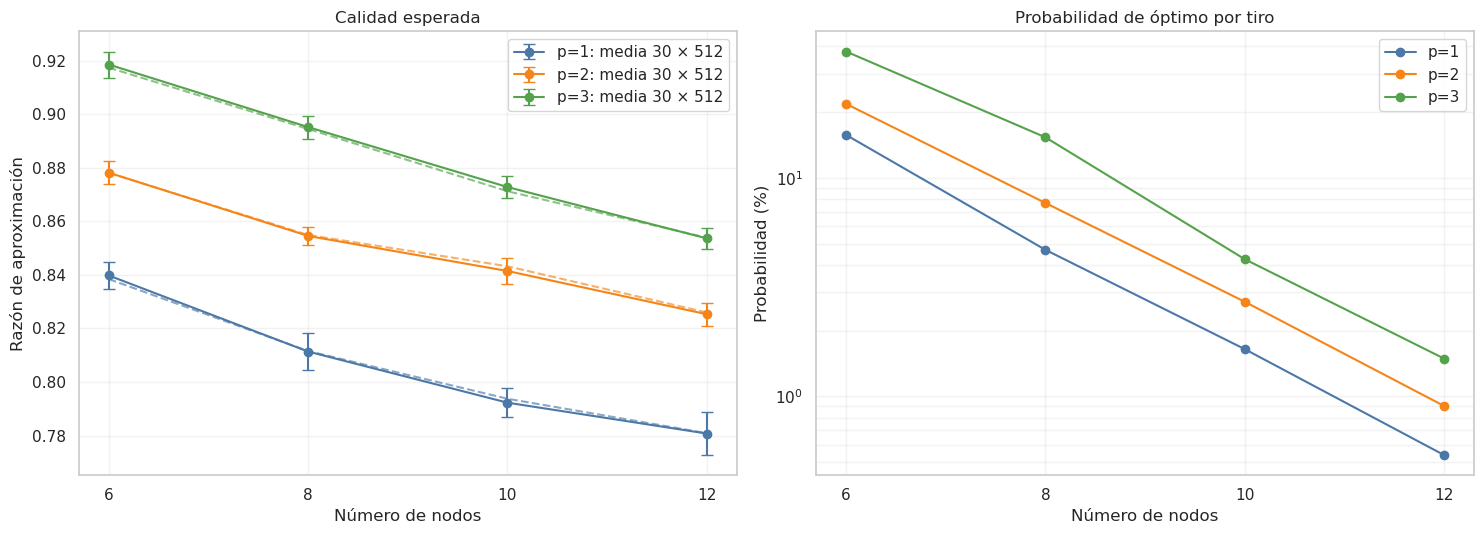

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
colores_p = {1: "#4C78A8", 2: "#F58518", 3: "#54A24B"}
fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))

for p in PROFUNDIDADES:
    datos = df_resumen_mediciones[df_resumen_mediciones["p"].eq(p)].sort_values("n")
    ejes[0].errorbar(
        datos["n"], datos["razon_muestral_media"],
        yerr=datos["razon_muestral_std"], marker="o", capsize=4,
        color=colores_p[p], label=f"p={p}: media 30 × 512"
    )
    ejes[0].plot(datos["n"], datos["razon_ideal"], "--", color=colores_p[p], alpha=.65)
    ejes[1].semilogy(
        datos["n"], 100 * datos["probabilidad_optimo_ideal"],
        marker="o", color=colores_p[p], label=f"p={p}"
    )

ejes[0].set(title="Calidad esperada", xlabel="Número de nodos", ylabel="Razón de aproximación")
ejes[1].set(title="Probabilidad de óptimo por tiro", xlabel="Número de nodos", ylabel="Probabilidad (%)")
for ax in ejes:
    ax.set_xticks(TAMANOS)
    ax.grid(alpha=.25, which="both")
    ax.legend()
fig.tight_layout()
plt.show()

### Comparación con métodos clásicos por rendimiento medio

Los presupuestos no son idénticos y deben conservarse en la tabla. El objetivo es describir el rendimiento observado, no proclamar una ventaja cuántica.

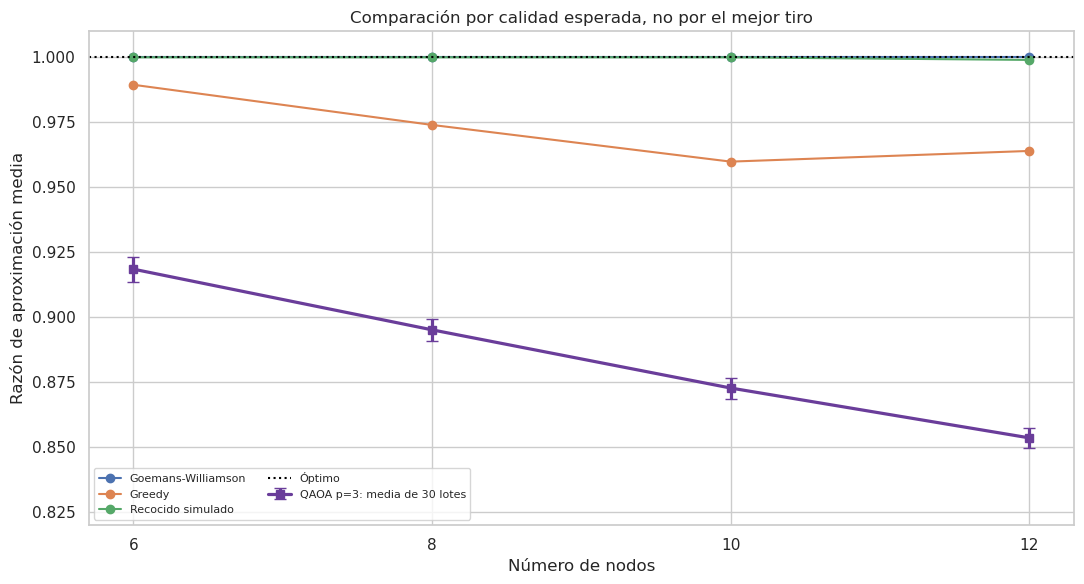

,n,metodo,razon_media,desviacion,ejecuciones
1,6,Greedy,0.989440,1.481623e+00,100
2,6,Recocido simulado,1.000000,7.141223e-14,100
3,6,Goemans-Williamson,1.000000,3.981030e-13,1000
6,8,Greedy,0.973997,2.278068e+00,100
7,8,Recocido simulado,1.000000,7.855346e-14,100
8,8,Goemans-Williamson,1.000000,4.834108e-13,1000
11,10,Greedy,0.959880,4.247351e+00,100
12,10,Recocido simulado,1.000000,9.997712e-14,100
13,10,Goemans-Williamson,1.000000,4.834108e-13,1000
16,12,Greedy,0.963989,3.806259e+00,100


,n,razon_muestral_media,razon_muestral_std
2,6,0.918513,0.004864
5,8,0.895175,0.004278
8,10,0.872790,0.004041
11,12,0.853617,0.003967


In [18]:
q3 = df_resumen_mediciones[df_resumen_mediciones["p"].eq(3)].copy()
clasicos_media = df_baseline[df_baseline["metodo"].isin([
    "Greedy", "Recocido simulado", "Goemans-Williamson"
])].copy()

fig, ax = plt.subplots(figsize=(11, 6))
for metodo, datos in clasicos_media.groupby("metodo"):
    datos = datos.sort_values("n")
    ax.plot(datos["n"], datos["razon_media"], marker="o", label=metodo)
ax.errorbar(
    q3["n"], q3["razon_muestral_media"], yerr=q3["razon_muestral_std"],
    marker="s", capsize=4, linewidth=2.3, color="#6A3D9A",
    label="QAOA p=3: media de 30 lotes"
)
ax.axhline(1, color="black", linestyle=":", label="Óptimo")
ax.set(
    title="Comparación por calidad esperada, no por el mejor tiro",
    xlabel="Número de nodos", ylabel="Razón de aproximación media", ylim=(.82, 1.01)
)
ax.set_xticks(TAMANOS)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

display(clasicos_media[["n", "metodo", "razon_media", "desviacion", "ejecuciones"]])
display(q3[["n", "razon_muestral_media", "razon_muestral_std"]])

### Intercambio calidad–profundidad y estabilidad de la optimización

,n,p,razon_ideal,probabilidad_optimo_ideal,operaciones_zz,operaciones_rx,delta_razon,delta_zz,ganancia_por_zz
0,6,1,0.838432,0.157418,5,6,NaN,NaN,NaN
1,6,2,0.878059,0.218421,10,12,0.039627,5.0,0.007925
2,6,3,0.917346,0.379235,15,18,0.039287,5.0,0.007857
3,8,1,0.811577,0.046878,7,8,NaN,NaN,NaN
4,8,2,0.854904,0.076807,14,16,0.043327,7.0,0.006190
5,8,3,0.894451,0.153491,21,24,0.039546,7.0,0.005649
6,10,1,0.793778,0.016451,9,10,NaN,NaN,NaN
7,10,2,0.843226,0.027111,18,20,0.049448,9.0,0.005494
8,10,3,0.871222,0.042464,27,30,0.027996,9.0,0.003111
9,12,1,0.780929,0.005385,11,12,NaN,NaN,NaN


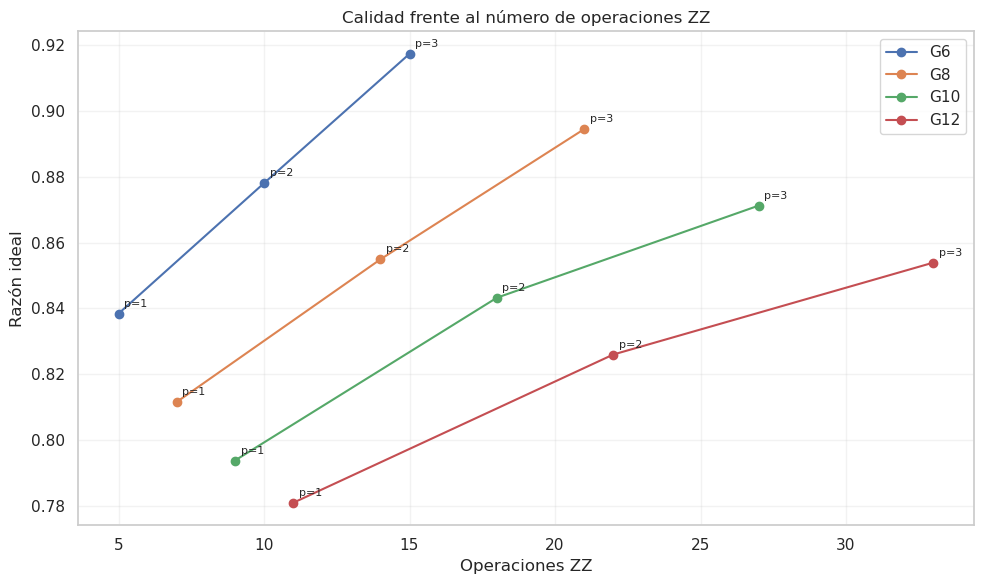

,reinicios,convergencias,media,mediana,desviacion,mejor_reinicio
n,,,,,,
6,12,12,0.894400,0.897702,0.026331,0.917346
8,12,12,0.874362,0.894451,0.027438,0.894451
10,12,12,0.853308,0.858453,0.023226,0.871222
12,12,11,0.839588,0.853893,0.022045,0.853893


In [19]:
tradeoff = df_resumen_mediciones[[
    "n", "p", "razon_ideal", "probabilidad_optimo_ideal"
]].copy()
tradeoff["operaciones_zz"] = (tradeoff["n"] - 1) * tradeoff["p"]
tradeoff["operaciones_rx"] = tradeoff["n"] * tradeoff["p"]
tradeoff = tradeoff.sort_values(["n", "p"])
tradeoff["delta_razon"] = tradeoff.groupby("n")["razon_ideal"].diff()
tradeoff["delta_zz"] = tradeoff.groupby("n")["operaciones_zz"].diff()
tradeoff["ganancia_por_zz"] = tradeoff["delta_razon"] / tradeoff["delta_zz"]
display(tradeoff.round(6))

fig, ax = plt.subplots(figsize=(10, 6))
for n, datos in tradeoff.groupby("n"):
    datos = datos.sort_values("p")
    ax.plot(datos["operaciones_zz"], datos["razon_ideal"], marker="o", label=f"G{n}")
    for _, fila in datos.iterrows():
        ax.annotate(f"p={int(fila.p)}", (fila.operaciones_zz, fila.razon_ideal), xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set(title="Calidad frente al número de operaciones ZZ", xlabel="Operaciones ZZ", ylabel="Razón ideal")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

p3_reinicios = df_optimizacion_qaoa[df_optimizacion_qaoa["p"].eq(3)]
display(p3_reinicios.groupby("n").agg(
    reinicios=("razon_esperada", "size"),
    convergencias=("convergencia_scipy", "sum"),
    media=("razon_esperada", "mean"),
    mediana=("razon_esperada", "median"),
    desviacion=("razon_esperada", "std"),
    mejor_reinicio=("razon_esperada", "max")
).round(6))

**Lectura correcta:** el mejor reinicio se selecciona de forma explícita para la solución final; la media y la dispersión entre reinicios describen la dificultad de la optimización clásica. Las 30 repeticiones de medición describen únicamente incertidumbre de tiros del mismo estado ideal optimizado.

### comprobar el entorno Guppy

In [20]:
from importlib.metadata import (
    version,
    PackageNotFoundError,
)


paquetes = [
    "guppylang",
    "qnexus",
    "selene-sim",
    "hugr",
]

print("Versiones instaladas:")

for paquete in paquetes:
    try:
        print(
            f"  {paquete}: "
            f"{version(paquete)}"
        )
    except PackageNotFoundError:
        print(
            f"  {paquete}: no identificado"
        )


# Importaciones compatibles con la versión
# de Guppy usada previamente.
from guppylang import guppy

from guppylang.std.builtins import (
    array,
    comptime,
    result,
)

from guppylang.std.quantum import (
    h,
    measure_array,
    qubit,
    rx,
)


# La ubicación de zz_phase cambia
# entre versiones de Guppy.
try:
    from guppylang.std.qsystem import (
        zz_phase,
    )
    
    RUTA_ZZ_PHASE = (
        "guppylang.std.qsystem"
    )

except ImportError:
    from guppylang.std.qsystem.helios import (
        zz_phase,
    )
    
    RUTA_ZZ_PHASE = (
        "guppylang.std.qsystem.helios"
    )


print("\nImportaciones Guppy correctas.")
print("Salida de mediciones: result")
print("Compuerta de costo:", RUTA_ZZ_PHASE)

assert callable(guppy)
assert callable(h)
assert callable(rx)
assert callable(zz_phase)
assert callable(measure_array)
assert callable(result)

print(
    "\nEl entorno está preparado "
    "para construir QAOA en Guppy."
)

Versiones instaladas:
  guppylang: 0.21.16
  qnexus: 0.46.0
  selene-sim: 0.2.10
  hugr: 0.16.0

Importaciones Guppy correctas.
Salida de mediciones: result
Compuerta de costo: guppylang.std.qsystem

El entorno está preparado para construir QAOA en Guppy.


## Implementación y validación local en Guppy

### construir y ejecutar el piloto Guppy G6, p=1

In [21]:
import ast
from pathlib import Path

from guppylang.std.angles import pi

# ============================================================
# 1. Configuración del piloto
# ============================================================

N_GUPPY_PILOTO = 6
P_GUPPY_PILOTO = 1
SHOTS_GUPPY_PILOTO = 512
SEED_GUPPY_PILOTO = 2026


columnas_requeridas = {
    "n",
    "p",
    "gammas_fisicos",
    "betas",
}

faltantes = (
    columnas_requeridas
    - set(df_mejores_qaoa.columns)
)

assert not faltantes, (
    "Faltan columnas en df_mejores_qaoa: "
    f"{sorted(faltantes)}"
)


# ============================================================
# 2. Recuperar los parámetros optimizados
# ============================================================

mascara_piloto = (
    pd.to_numeric(
        df_mejores_qaoa["n"],
        errors="coerce",
    ).eq(N_GUPPY_PILOTO)
    &
    pd.to_numeric(
        df_mejores_qaoa["p"],
        errors="coerce",
    ).eq(P_GUPPY_PILOTO)
)

filas_piloto = (
    df_mejores_qaoa.loc[
        mascara_piloto
    ].copy()
)

assert len(filas_piloto) == 1, (
    "Se esperaba exactamente una fila "
    "para G6 con p=1."
)

fila_piloto = filas_piloto.iloc[0]


def convertir_a_lista_float(valor):
    """
    Convierte listas, arrays o cadenas
    de parámetros en una lista de float.
    """

    if isinstance(valor, str):
        texto = valor.strip()

        if (
            texto.startswith("array(")
            and texto.endswith(")")
        ):
            texto = texto[
                len("array("):-1
            ]

        try:
            valor = ast.literal_eval(texto)

        except (ValueError, SyntaxError):
            texto = (
                texto
                .replace("[", "")
                .replace("]", "")
                .replace(",", " ")
            )

            valor = np.fromstring(
                texto,
                sep=" ",
            )

    vector = np.asarray(
        valor,
        dtype=float,
    ).reshape(-1)

    assert np.isfinite(vector).all(), (
        "El vector contiene valores no finitos."
    )

    return [
        float(x)
        for x in vector
    ]


GAMMAS_GUPPY_PILOTO = (
    convertir_a_lista_float(
        fila_piloto["gammas_fisicos"]
    )
)

BETAS_GUPPY_PILOTO = (
    convertir_a_lista_float(
        fila_piloto["betas"]
    )
)

assert (
    len(GAMMAS_GUPPY_PILOTO)
    == P_GUPPY_PILOTO
)

assert (
    len(BETAS_GUPPY_PILOTO)
    == P_GUPPY_PILOTO
)

print(
    "Gammas físicos:",
    GAMMAS_GUPPY_PILOTO,
)

print(
    "Betas:",
    BETAS_GUPPY_PILOTO,
)


# ============================================================
# 3. Localizar los archivos originales de G6
# ============================================================

def buscar_archivo_guppy(nombre):
    bases = [
        Path("."),
        ROOT / "datos" / "grafos",
    ]

    nombres_variables_ruta = [
        "RESULTADOS",
        "RESULTADOS_QAOA",
        "CARPETA_RESULTADOS",
        "RUTA_RESULTADOS",
        "BASE_RESULTADOS",
    ]

    for nombre_variable in nombres_variables_ruta:
        valor = globals().get(nombre_variable)

        if valor is not None:
            try:
                bases.append(Path(valor))
            except TypeError:
                pass

    rutas_probadas = []

    for base in bases:
        candidato = base / nombre
        rutas_probadas.append(candidato)

        if candidato.exists():
            return candidato

    raise FileNotFoundError(
        f"No se encontró {nombre}. "
        f"Rutas probadas: {rutas_probadas}"
    )


ruta_nodos_g6 = buscar_archivo_guppy(
    "grafo_6_nodos.csv"
)

ruta_aristas_g6 = buscar_archivo_guppy(
    "grafo_6_aristas.csv"
)

nodos_g6_guppy = pd.read_csv(
    ruta_nodos_g6
)

aristas_g6_guppy = pd.read_csv(
    ruta_aristas_g6
)

assert {
    "node_id",
}.issubset(
    nodos_g6_guppy.columns
)

columna_source_g6 = (
    "source"
    if "source" in aristas_g6_guppy.columns
    else "source_id"
)
columna_target_g6 = (
    "target"
    if "target" in aristas_g6_guppy.columns
    else "target_id"
)
assert {
    columna_source_g6,
    columna_target_g6,
    "weight",
}.issubset(aristas_g6_guppy.columns)


# Mantener exactamente el orden del archivo de nodos.
ids_nodos_g6 = (
    nodos_g6_guppy["node_id"]
    .astype(str)
    .str.strip()
    .tolist()
)

nodo_a_qubit_g6 = {
    node_id: indice
    for indice, node_id
    in enumerate(ids_nodos_g6)
}

assert len(nodo_a_qubit_g6) == 6, (
    "G6 no contiene exactamente "
    "seis identificadores únicos."
)


# Debe ser una lista para comptime.
ARISTAS_GUPPY_PILOTO = []

for _, fila in aristas_g6_guppy.iterrows():
    source = str(
        fila[columna_source_g6]
    ).strip()

    target = str(
        fila[columna_target_g6]
    ).strip()

    assert source in nodo_a_qubit_g6, (
        f"Nodo source desconocido: {source}"
    )

    assert target in nodo_a_qubit_g6, (
        f"Nodo target desconocido: {target}"
    )

    peso = float(
        fila["weight"]
    )

    assert np.isfinite(peso)
    assert peso > 0.0

    ARISTAS_GUPPY_PILOTO.append(
        (
            int(nodo_a_qubit_g6[source]),
            int(nodo_a_qubit_g6[target]),
            peso,
        )
    )


assert len(ARISTAS_GUPPY_PILOTO) == 5, (
    "G6 debería tener cinco aristas."
)

print(
    "\nArchivo de nodos:",
    ruta_nodos_g6,
)

print(
    "Archivo de aristas:",
    ruta_aristas_g6,
)

print(
    "Aristas Guppy:",
    ARISTAS_GUPPY_PILOTO,
)


# ============================================================
# 4. Constructor general QAOA para Guppy 0.21.16
# ============================================================

def crear_programa_guppy_qaoa(
    n_qubits,
    aristas,
    gammas_fisicos,
    betas,
    shots=512,
    seed=2026,
):
    n_qubits = int(n_qubits)

    assert len(gammas_fisicos) == len(betas)
    assert len(gammas_fisicos) >= 1

    aristas_compilacion = [
        (
            int(i),
            int(j),
            float(weight),
        )
        for i, j, weight in aristas
    ]

    # Los parámetros de la optimización están en radianes.
    # Guppy representa sus ángulos como múltiplos de pi.
    capas_compilacion = [
        (
            float(gamma) / np.pi,
            float(beta) / np.pi,
        )
        for gamma, beta
        in zip(
            gammas_fisicos,
            betas,
        )
    ]

    @guppy
    def main_qaoa_guppy() -> None:
        """
        Entrypoint sin argumentos.
        Los parámetros se incorporan como
        constantes de compilación.
        """

        qs = array(
            qubit()
            for _ in range(
                comptime(n_qubits)
            )
        )

        # Estado inicial |+>^n.
        for i in range(
            comptime(n_qubits)
        ):
            h(qs[i])

        # Capas QAOA.
        for (
            gamma_sobre_pi,
            beta_sobre_pi,
        ) in comptime(
            capas_compilacion
        ):

            # Hamiltoniano de costo.
            for (
                i,
                j,
                weight,
            ) in comptime(
                aristas_compilacion
            ):
                zz_phase(
                qs[i],
                qs[j],
                (
                    -gamma_sobre_pi
                    * weight
                    * pi
                ),
            )
            # Hamiltoniano mezclador.
            for i in range(
                comptime(n_qubits)
            ):
                rx(
                    qs[i],
                    (
                        2.0
                        * beta_sobre_pi
                        * pi
                    ),
                )

        result(
            "c",
            measure_array(qs),
        )

    # Detectar errores antes de ejecutar.
    main_qaoa_guppy.check()

    return (
        main_qaoa_guppy
        .emulator(
            n_qubits=n_qubits
        )
        .with_shots(
            int(shots)
        )
        .with_seed(
            int(seed)
        )
    )


# ============================================================
# 5. Compilar y ejecutar G6 con p=1
# ============================================================

programa_guppy_piloto = (
    crear_programa_guppy_qaoa(
        n_qubits=N_GUPPY_PILOTO,
        aristas=ARISTAS_GUPPY_PILOTO,
        gammas_fisicos=GAMMAS_GUPPY_PILOTO,
        betas=BETAS_GUPPY_PILOTO,
        shots=SHOTS_GUPPY_PILOTO,
        seed=SEED_GUPPY_PILOTO,
    )
)

print(
    "\nPrograma Guppy compilado correctamente."
)

resultado_guppy_piloto = (
    programa_guppy_piloto.run()
)

conteos_guppy_piloto = (
    resultado_guppy_piloto
    .register_counts()["c"]
)

shots_recibidos = sum(
    conteos_guppy_piloto.values()
)

assert (
    shots_recibidos
    == SHOTS_GUPPY_PILOTO
), (
    "El número de mediciones no coincide "
    "con los shots solicitados."
)

print("Ejecución local terminada.")
print("Shots recibidos:", shots_recibidos)
print(
    "Estados distintos observados:",
    len(conteos_guppy_piloto),
)

print("\nPrimeros conteos:")
print(
    conteos_guppy_piloto.most_common(10)
)

Gammas físicos: [0.09611652644354386]
Betas: [0.392699093243063]

Archivo de nodos: ../resultados/grafo_6_nodos.csv
Archivo de aristas: ../resultados/grafo_6_aristas.csv
Aristas Guppy: [(0, 1, 13.244501862), (0, 2, 1.96714567), (0, 3, 2.914285793), (1, 5, 5.77783263), (4, 5, 14.398023623)]

Programa Guppy compilado correctamente.
Ejecución local terminada.
Shots recibidos: 512
Estados distintos observados: 41

Primeros conteos:
[('011110', 48), ('011001', 42), ('101001', 37), ('100001', 36), ('010110', 34), ('100010', 31), ('101010', 30), ('100110', 29), ('100101', 29), ('011101', 28)]


In [22]:
# ============================================================
# VALIDACIÓN DE LAS MEDICIONES DEL PILOTO G6, p=1
# ============================================================
def costo_bitstring_guppy(
    bitstring,
    aristas,
    n_qubits,
):
    bits = [
        int(bit)
        for bit in str(bitstring)
    ]

    assert len(bits) == n_qubits, (
        f"Bitstring inesperado: {bitstring}"
    )

    return float(
        sum(
            weight
            for i, j, weight in aristas
            if bits[i] != bits[j]
        )
    )


registros_guppy_piloto = []

for bitstring, frecuencia in (
    conteos_guppy_piloto.items()
):
    costo = costo_bitstring_guppy(
        bitstring=bitstring,
        aristas=ARISTAS_GUPPY_PILOTO,
        n_qubits=N_GUPPY_PILOTO,
    )

    registros_guppy_piloto.append({
        "bitstring": str(bitstring),
        "frecuencia": int(frecuencia),
        "probabilidad": (
            int(frecuencia)
            / SHOTS_GUPPY_PILOTO
        ),
        "costo": costo,
    })


df_guppy_piloto = (
    pd.DataFrame(
        registros_guppy_piloto
    )
    .sort_values(
        [
            "costo",
            "frecuencia",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


OPTIMO_GUPPY_PILOTO = float(
    OPTIMOS_EXACTOS[
        N_GUPPY_PILOTO
    ]
)

COSTO_ESPERADO_GUPPY = float(
    (
        df_guppy_piloto["probabilidad"]
        * df_guppy_piloto["costo"]
    ).sum()
)

RAZON_GUPPY_PILOTO = (
    COSTO_ESPERADO_GUPPY
    / OPTIMO_GUPPY_PILOTO
)

MEJOR_COSTO_GUPPY = float(
    df_guppy_piloto["costo"].max()
)

PROBABILIDAD_OPTIMO_GUPPY = float(
    df_guppy_piloto.loc[
        np.isclose(
            df_guppy_piloto["costo"],
            OPTIMO_GUPPY_PILOTO,
            atol=1e-6,
        ),
        "probabilidad",
    ].sum()
)


# ============================================================
# 4. Recuperar el resultado ideal correspondiente
# ============================================================

mascara_ideal_piloto = (
    pd.to_numeric(
        df_resumen_mediciones["n"],
        errors="coerce",
    ).eq(N_GUPPY_PILOTO)
    &
    pd.to_numeric(
        df_resumen_mediciones["p"],
        errors="coerce",
    ).eq(P_GUPPY_PILOTO)
)

fila_ideal_piloto = (
    df_resumen_mediciones.loc[
        mascara_ideal_piloto
    ]
)

assert len(fila_ideal_piloto) == 1

RAZON_IDEAL_PILOTO = float(
    fila_ideal_piloto.iloc[0][
        "razon_ideal"
    ]
)

ERROR_GUPPY_IDEAL = abs(
    RAZON_GUPPY_PILOTO
    - RAZON_IDEAL_PILOTO
)


# ============================================================
# 5. Mostrar y validar los resultados corregidos
# ============================================================

resumen_guppy_piloto = pd.DataFrame([
    {
        "n": N_GUPPY_PILOTO,
        "p": P_GUPPY_PILOTO,
        "shots": SHOTS_GUPPY_PILOTO,
        "razon_ideal": RAZON_IDEAL_PILOTO,
        "razon_guppy": RAZON_GUPPY_PILOTO,
        "error_absoluto": ERROR_GUPPY_IDEAL,
        "mejor_costo": MEJOR_COSTO_GUPPY,
        "optimo_exacto": OPTIMO_GUPPY_PILOTO,
        "probabilidad_optimo": (
            PROBABILIDAD_OPTIMO_GUPPY
        ),
    }
])

display(resumen_guppy_piloto)
display(df_guppy_piloto.head(10))

assert ERROR_GUPPY_IDEAL <= 0.05, (
    "La razón de aproximación observada en Guppy "
    "se aleja más de 0.05 del valor ideal."
)

assert np.isclose(
    MEJOR_COSTO_GUPPY,
    OPTIMO_GUPPY_PILOTO,
    atol=1e-6,
), (
    "El piloto no observó la solución óptima."
)

print(
    "\nPiloto Guppy G6, p=1 "
    "validado correctamente."
)

,n,p,shots,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo
0,6,1,512,0.838432,0.838697,0.000265,38.30179,38.30179,0.164062


,bitstring,frecuencia,probabilidad,costo
0,011110,48,0.093750,38.301790
1,100001,36,0.070312,38.301790
2,101001,37,0.072266,36.334644
3,010110,34,0.066406,36.334644
4,100101,29,0.056641,35.387504
5,011010,22,0.042969,35.387504
6,010010,24,0.046875,33.420358
7,101101,16,0.031250,33.420358
8,100010,31,0.060547,32.523957
9,011101,28,0.054688,32.523957



Piloto Guppy G6, p=1 validado correctamente.


Los cuatro subgrafos regionales construidos a partir de los datos oficiales disponibles del ICE son árboles ponderados, conexos y bipartitos. Debido a esta estructura, existe una bipartición capaz de cortar todas las aristas, por lo que el valor óptimo de Max-Cut coincide con la suma total de sus pesos. Esta propiedad no invalida las instancias, sino que proporciona una referencia exacta para evaluar objetivamente el desempeño de QAOA. El experimento se concentra en analizar la razón de aproximación, la probabilidad de obtener la solución óptima, el efecto de la profundidad del circuito y la escalabilidad de la implementación desarrollada en Guppy.

In [23]:
# ============================================================
# BLOQUE 6A
# PREPARAR TODAS LAS CONFIGURACIONES PARA GUPPY
# ============================================================

TAMANOS_GUPPY = [
    6,
    8,
    10,
    12,
]

PROFUNDIDADES_GUPPY = [
    1,
    2,
    3,
]


# ============================================================
# 1. Cargar un grafo de cualquier tamaño
# ============================================================

def cargar_instancia_guppy(n):
    """
    Carga los archivos de nodos y aristas de Gn,
    conserva el orden original de los nodos y
    convierte sus identificadores en índices
    de qubits: 0, 1, ..., n-1.
    """

    n = int(n)

    ruta_nodos = buscar_archivo_guppy(
        f"grafo_{n}_nodos.csv"
    )

    ruta_aristas = buscar_archivo_guppy(
        f"grafo_{n}_aristas.csv"
    )

    df_nodos = pd.read_csv(
        ruta_nodos
    )

    df_aristas = pd.read_csv(
        ruta_aristas
    )

    assert "node_id" in df_nodos.columns, (
        f"El archivo de nodos de G{n} "
        "no contiene node_id."
    )

    columna_source = (
        "source"
        if "source" in df_aristas.columns
        else "source_id"
    )
    columna_target = (
        "target"
        if "target" in df_aristas.columns
        else "target_id"
    )
    assert {
        columna_source,
        columna_target,
        "weight",
    }.issubset(df_aristas.columns), (
        f"El archivo de aristas de G{n} "
        "no tiene las columnas requeridas."
    )

    # Conservar el orden original del CSV.
    ids_nodos = (
        df_nodos["node_id"]
        .astype(str)
        .str.strip()
        .tolist()
    )

    assert len(ids_nodos) == n, (
        f"G{n} contiene {len(ids_nodos)} nodos."
    )

    assert len(set(ids_nodos)) == n, (
        f"G{n} contiene identificadores repetidos."
    )

    nodo_a_qubit = {
        node_id: indice
        for indice, node_id
        in enumerate(ids_nodos)
    }

    # Debe permanecer como lista para comptime.
    aristas_guppy = []
    aristas_vistas = set()

    for _, fila in df_aristas.iterrows():

        source = str(
            fila[columna_source]
        ).strip()

        target = str(
            fila[columna_target]
        ).strip()

        assert source in nodo_a_qubit, (
            f"Nodo source desconocido en G{n}: "
            f"{source}"
        )

        assert target in nodo_a_qubit, (
            f"Nodo target desconocido en G{n}: "
            f"{target}"
        )

        i = int(
            nodo_a_qubit[source]
        )

        j = int(
            nodo_a_qubit[target]
        )

        peso = float(
            fila["weight"]
        )

        assert i != j, (
            f"G{n} contiene un bucle en el nodo {i}."
        )

        assert np.isfinite(peso), (
            f"G{n} contiene un peso no finito."
        )

        assert peso > 0.0, (
            f"G{n} contiene un peso no positivo."
        )

        clave_arista = tuple(
            sorted((i, j))
        )

        assert clave_arista not in aristas_vistas, (
            f"G{n} contiene una arista duplicada: "
            f"{clave_arista}"
        )

        aristas_vistas.add(
            clave_arista
        )

        aristas_guppy.append(
            (
                i,
                j,
                peso,
            )
        )

    # Comprobar que el grafo está conectado.
    grafo_validacion = nx.Graph()

    grafo_validacion.add_nodes_from(
        range(n)
    )

    grafo_validacion.add_weighted_edges_from(
        aristas_guppy
    )

    assert nx.is_connected(
        grafo_validacion
    ), (
        f"G{n} no está conectado."
    )

    return {
        "n": n,
        "ruta_nodos": ruta_nodos,
        "ruta_aristas": ruta_aristas,
        "ids_nodos": ids_nodos,
        "nodo_a_qubit": nodo_a_qubit,
        "aristas": aristas_guppy,
    }


# ============================================================
# 2. Recuperar los parámetros de una configuración
# ============================================================

def obtener_parametros_guppy(n, p):
    """
    Recupera de df_mejores_qaoa los parámetros
    optimizados para una combinación Gn y p.
    """

    mascara = (
        pd.to_numeric(
            df_mejores_qaoa["n"],
            errors="coerce",
        ).eq(int(n))
        &
        pd.to_numeric(
            df_mejores_qaoa["p"],
            errors="coerce",
        ).eq(int(p))
    )

    filas = (
        df_mejores_qaoa.loc[
            mascara
        ]
    )

    assert len(filas) == 1, (
        "Se esperaba exactamente una fila "
        f"para G{n}, p={p}; "
        f"se encontraron {len(filas)}."
    )

    fila = filas.iloc[0]

    gammas = convertir_a_lista_float(
        fila["gammas_fisicos"]
    )

    betas = convertir_a_lista_float(
        fila["betas"]
    )

    assert len(gammas) == p, (
        f"G{n}, p={p}: cantidad incorrecta "
        "de gammas."
    )

    assert len(betas) == p, (
        f"G{n}, p={p}: cantidad incorrecta "
        "de betas."
    )

    return gammas, betas


# ============================================================
# 3. Construir las 12 configuraciones
# ============================================================

CONFIGURACIONES_GUPPY = {}
filas_configuraciones = []

for n in TAMANOS_GUPPY:

    instancia = cargar_instancia_guppy(
        n
    )

    for p in PROFUNDIDADES_GUPPY:

        gammas, betas = (
            obtener_parametros_guppy(
                n=n,
                p=p,
            )
        )

        CONFIGURACIONES_GUPPY[
            (n, p)
        ] = {
            "n_qubits": n,
            "p": p,
            "aristas": instancia["aristas"],
            "gammas_fisicos": gammas,
            "betas": betas,
            "ids_nodos": instancia["ids_nodos"],
        }

        filas_configuraciones.append({
            "grafo": f"G{n}",
            "n": n,
            "p": p,
            "n_aristas": len(
                instancia["aristas"]
            ),
            "n_gammas": len(gammas),
            "n_betas": len(betas),
        })


df_configuraciones_guppy = (
    pd.DataFrame(
        filas_configuraciones
    )
    .sort_values(
        [
            "n",
            "p",
        ]
    )
    .reset_index(drop=True)
)

display(
    df_configuraciones_guppy
)


# ============================================================
# 4. Validaciones finales
# ============================================================

assert len(
    CONFIGURACIONES_GUPPY
) == 12, (
    "No se prepararon las 12 configuraciones."
)

assert len(
    df_configuraciones_guppy
) == 12

print(
    "\nLas 12 configuraciones Guppy "
    "fueron preparadas correctamente."
)

,grafo,n,p,n_aristas,n_gammas,n_betas
0,G6,6,1,5,1,1
1,G6,6,2,5,2,2
2,G6,6,3,5,3,3
3,G8,8,1,7,1,1
4,G8,8,2,7,2,2
5,G8,8,3,7,3,3
6,G10,10,1,9,1,1
7,G10,10,2,9,2,2
8,G10,10,3,9,3,3
9,G12,12,1,11,1,1



Las 12 configuraciones Guppy fueron preparadas correctamente.


In [24]:
# ============================================================
# BLOQUE 6B
# PRUEBA LOCAL DE G6 CON p=2
# ============================================================

SHOTS_GUPPY_LOCAL = 512
SEED_GUPPY_LOCAL = 2026


# Recuperar la configuración ya preparada.
configuracion_g6_p2 = (
    CONFIGURACIONES_GUPPY[
        (6, 2)
    ]
)


# Verificar su contenido antes de compilar.
assert configuracion_g6_p2["n_qubits"] == 6
assert configuracion_g6_p2["p"] == 2

assert len(
    configuracion_g6_p2["gammas_fisicos"]
) == 2

assert len(
    configuracion_g6_p2["betas"]
) == 2


print("Configuración seleccionada: G6, p=2")

print(
    "Gammas físicos:",
    configuracion_g6_p2[
        "gammas_fisicos"
    ],
)

print(
    "Betas:",
    configuracion_g6_p2[
        "betas"
    ],
)

print(
    "Número de aristas:",
    len(
        configuracion_g6_p2[
            "aristas"
        ]
    ),
)


# ============================================================
# CONSTRUIR Y COMPILAR EL PROGRAMA
# ============================================================

programa_guppy_g6_p2 = (
    crear_programa_guppy_qaoa(
        n_qubits=(
            configuracion_g6_p2[
                "n_qubits"
            ]
        ),
        aristas=(
            configuracion_g6_p2[
                "aristas"
            ]
        ),
        gammas_fisicos=(
            configuracion_g6_p2[
                "gammas_fisicos"
            ]
        ),
        betas=(
            configuracion_g6_p2[
                "betas"
            ]
        ),
        shots=SHOTS_GUPPY_LOCAL,
        seed=SEED_GUPPY_LOCAL,
    )
)

print(
    "\nPrograma G6, p=2 "
    "compilado correctamente."
)


# ============================================================
# EJECUTAR EN EL EMULADOR LOCAL
# ============================================================

resultado_guppy_g6_p2 = (
    programa_guppy_g6_p2.run()
)

conteos_guppy_g6_p2 = (
    resultado_guppy_g6_p2
    .register_counts()["c"]
)

shots_recibidos_g6_p2 = sum(
    conteos_guppy_g6_p2.values()
)


# ============================================================
# VALIDAR LA EJECUCIÓN
# ============================================================

assert (
    shots_recibidos_g6_p2
    == SHOTS_GUPPY_LOCAL
), (
    "El número de mediciones recibidas "
    "no coincide con los shots solicitados."
)

assert all(
    len(str(bitstring)) == 6
    for bitstring
    in conteos_guppy_g6_p2
), (
    "Se encontró un resultado con una "
    "cantidad incorrecta de bits."
)


print("\nEjecución local terminada.")
print(
    "Shots recibidos:",
    shots_recibidos_g6_p2,
)

print(
    "Estados distintos observados:",
    len(conteos_guppy_g6_p2),
)

print("\nDiez resultados más frecuentes:")

print(
    conteos_guppy_g6_p2.most_common(10)
)

Configuración seleccionada: G6, p=2
Gammas físicos: [0.06648079698606009, 0.14281062466940617]
Betas: [0.5370872586705523, 0.23408295423699593]
Número de aristas: 5

Programa G6, p=2 compilado correctamente.

Ejecución local terminada.
Shots recibidos: 512
Estados distintos observados: 28

Diez resultados más frecuentes:
[('011110', 63), ('100001', 51), ('010110', 45), ('101001', 44), ('011101', 43), ('100010', 34), ('100101', 33), ('011010', 28), ('100110', 25), ('101010', 23)]


In [25]:
# ============================================================
# BLOQUE 6C
# EVALUAR LOS RESULTADOS DE G6 CON p=2
# ============================================================

N_GUPPY_G6_P2 = 6
P_GUPPY_G6_P2 = 2

aristas_g6_p2 = (
    configuracion_g6_p2["aristas"]
)


# ============================================================
# 1. CALCULAR EL COSTO DE CADA ESTADO OBSERVADO
# ============================================================

registros_guppy_g6_p2 = []

for bitstring, frecuencia in (
    conteos_guppy_g6_p2.items()
):
    costo = costo_bitstring_guppy(
        bitstring=bitstring,
        aristas=aristas_g6_p2,
        n_qubits=N_GUPPY_G6_P2,
    )

    registros_guppy_g6_p2.append({
        "bitstring": str(bitstring),
        "frecuencia": int(frecuencia),
        "probabilidad": (
            int(frecuencia)
            / shots_recibidos_g6_p2
        ),
        "costo": float(costo),
    })


df_guppy_g6_p2 = (
    pd.DataFrame(
        registros_guppy_g6_p2
    )
    .sort_values(
        [
            "costo",
            "frecuencia",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# Las probabilidades deben sumar 1.
assert np.isclose(
    df_guppy_g6_p2[
        "probabilidad"
    ].sum(),
    1.0,
), (
    "Las probabilidades no suman 1."
)


# ============================================================
# 2. CALCULAR LAS MÉTRICAS DE QAOA
# ============================================================

OPTIMO_GUPPY_G6_P2 = float(
    OPTIMOS_EXACTOS[
        N_GUPPY_G6_P2
    ]
)


# Promedio ponderado del costo de todos los shots.
COSTO_ESPERADO_GUPPY_G6_P2 = float(
    (
        df_guppy_g6_p2["probabilidad"]
        * df_guppy_g6_p2["costo"]
    ).sum()
)


# Razón entre el costo esperado y el óptimo exacto.
RAZON_GUPPY_G6_P2 = (
    COSTO_ESPERADO_GUPPY_G6_P2
    / OPTIMO_GUPPY_G6_P2
)


# Mejor corte encontrado entre los 512 shots.
MEJOR_COSTO_GUPPY_G6_P2 = float(
    df_guppy_g6_p2["costo"].max()
)


# Probabilidad total de medir una solución óptima.
PROBABILIDAD_OPTIMO_GUPPY_G6_P2 = float(
    df_guppy_g6_p2.loc[
        np.isclose(
            df_guppy_g6_p2["costo"],
            OPTIMO_GUPPY_G6_P2,
            atol=1e-6,
        ),
        "probabilidad",
    ].sum()
)


# ============================================================
# 3. RECUPERAR EL RESULTADO IDEAL PARA G6, p=2
# ============================================================

mascara_ideal_g6_p2 = (
    pd.to_numeric(
        df_resumen_mediciones["n"],
        errors="coerce",
    ).eq(N_GUPPY_G6_P2)
    &
    pd.to_numeric(
        df_resumen_mediciones["p"],
        errors="coerce",
    ).eq(P_GUPPY_G6_P2)
)


fila_ideal_g6_p2 = (
    df_resumen_mediciones.loc[
        mascara_ideal_g6_p2
    ]
)

assert len(fila_ideal_g6_p2) == 1, (
    "No se encontró exactamente un "
    "resultado ideal para G6, p=2."
)


RAZON_IDEAL_G6_P2 = float(
    fila_ideal_g6_p2.iloc[0][
        "razon_ideal"
    ]
)


ERROR_GUPPY_IDEAL_G6_P2 = abs(
    RAZON_GUPPY_G6_P2
    - RAZON_IDEAL_G6_P2
)


# ============================================================
# 4. CREAR EL RESUMEN DE G6, p=2
# ============================================================

resumen_guppy_g6_p2 = pd.DataFrame([
    {
        "n": N_GUPPY_G6_P2,
        "p": P_GUPPY_G6_P2,
        "shots": shots_recibidos_g6_p2,
        "costo_esperado": (
            COSTO_ESPERADO_GUPPY_G6_P2
        ),
        "razon_ideal": (
            RAZON_IDEAL_G6_P2
        ),
        "razon_guppy": (
            RAZON_GUPPY_G6_P2
        ),
        "error_absoluto": (
            ERROR_GUPPY_IDEAL_G6_P2
        ),
        "mejor_costo": (
            MEJOR_COSTO_GUPPY_G6_P2
        ),
        "optimo_exacto": (
            OPTIMO_GUPPY_G6_P2
        ),
        "probabilidad_optimo": (
            PROBABILIDAD_OPTIMO_GUPPY_G6_P2
        ),
    }
])


display(
    resumen_guppy_g6_p2
)

print(
    "\nEstados con mayor costo:"
)

display(
    df_guppy_g6_p2.head(10)
)


# ============================================================
# 5. VALIDAR EL RESULTADO
# ============================================================

assert (
    ERROR_GUPPY_IDEAL_G6_P2
    <= 0.05
), (
    "La razón obtenida con Guppy se aleja "
    "más de 0.05 del resultado ideal."
)


assert (
    MEJOR_COSTO_GUPPY_G6_P2
    <= OPTIMO_GUPPY_G6_P2 + 1e-6
), (
    "Se obtuvo un costo superior al "
    "óptimo exacto."
)


assert np.isclose(
    MEJOR_COSTO_GUPPY_G6_P2,
    OPTIMO_GUPPY_G6_P2,
    atol=1e-6,
), (
    "No se observó la solución óptima."
)


print(
    "\nG6, p=2 fue validado correctamente."
)

,n,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo
0,6,2,512,33.874029,0.878059,0.884398,0.006339,38.30179,38.30179,0.222656



Estados con mayor costo:


,bitstring,frecuencia,probabilidad,costo
0,011110,63,0.123047,38.301790
1,100001,51,0.099609,38.301790
2,010110,45,0.087891,36.334644
3,101001,44,0.085938,36.334644
4,100101,33,0.064453,35.387504
5,011010,28,0.054688,35.387504
6,101101,23,0.044922,33.420358
7,010010,20,0.039062,33.420358
8,011101,43,0.083984,32.523957
9,100010,34,0.066406,32.523957



G6, p=2 fue validado correctamente.


In [26]:
# ============================================================
# BLOQUE 6D
# COMPARAR G6 CON p=1 Y p=2
# ============================================================

def resumir_resultado_guppy(
    df_estados,
    n,
    p,
):
    """
    Calcula las principales métricas de una ejecución
    Guppy utilizando la tabla de estados ya evaluados.
    """

    columnas_requeridas = {
        "bitstring",
        "frecuencia",
        "probabilidad",
        "costo",
    }

    assert columnas_requeridas.issubset(
        df_estados.columns
    ), (
        "La tabla no contiene todas las "
        "columnas requeridas."
    )

    optimo_exacto = float(
        OPTIMOS_EXACTOS[int(n)]
    )

    costo_esperado = float(
        (
            df_estados["probabilidad"]
            * df_estados["costo"]
        ).sum()
    )

    razon_guppy = (
        costo_esperado
        / optimo_exacto
    )

    mejor_costo = float(
        df_estados["costo"].max()
    )

    probabilidad_optimo = float(
        df_estados.loc[
            np.isclose(
                df_estados["costo"],
                optimo_exacto,
                atol=1e-6,
            ),
            "probabilidad",
        ].sum()
    )

    # Recuperar la razón ideal correspondiente.
    mascara_ideal = (
        pd.to_numeric(
            df_resumen_mediciones["n"],
            errors="coerce",
        ).eq(int(n))
        &
        pd.to_numeric(
            df_resumen_mediciones["p"],
            errors="coerce",
        ).eq(int(p))
    )

    fila_ideal = (
        df_resumen_mediciones.loc[
            mascara_ideal
        ]
    )

    assert len(fila_ideal) == 1, (
        f"No se encontró exactamente un "
        f"resultado ideal para G{n}, p={p}."
    )

    razon_ideal = float(
        fila_ideal.iloc[0][
            "razon_ideal"
        ]
    )

    return {
        "grafo": f"G{n}",
        "p": int(p),
        "shots": int(
            df_estados["frecuencia"].sum()
        ),
        "costo_esperado": costo_esperado,
        "razon_ideal": razon_ideal,
        "razon_guppy": razon_guppy,
        "error_absoluto": abs(
            razon_guppy
            - razon_ideal
        ),
        "mejor_costo": mejor_costo,
        "optimo_exacto": optimo_exacto,
        "probabilidad_optimo": (
            probabilidad_optimo
        ),
    }


# ============================================================
# 1. RESUMIR LAS DOS EJECUCIONES
# ============================================================

resultado_g6_p1 = resumir_resultado_guppy(
    df_estados=df_guppy_piloto,
    n=6,
    p=1,
)

resultado_g6_p2 = resumir_resultado_guppy(
    df_estados=df_guppy_g6_p2,
    n=6,
    p=2,
)


df_comparacion_g6 = pd.DataFrame([
    resultado_g6_p1,
    resultado_g6_p2,
])


# ============================================================
# 2. CALCULAR EL CAMBIO RESPECTO A p=1
# ============================================================

razon_base_p1 = float(
    df_comparacion_g6.loc[
        df_comparacion_g6["p"].eq(1),
        "razon_guppy",
    ].iloc[0]
)

probabilidad_base_p1 = float(
    df_comparacion_g6.loc[
        df_comparacion_g6["p"].eq(1),
        "probabilidad_optimo",
    ].iloc[0]
)


df_comparacion_g6[
    "cambio_razon_vs_p1"
] = (
    df_comparacion_g6["razon_guppy"]
    - razon_base_p1
)


df_comparacion_g6[
    "cambio_prob_optimo_vs_p1"
] = (
    df_comparacion_g6[
        "probabilidad_optimo"
    ]
    - probabilidad_base_p1
)


# ============================================================
# 3. MOSTRAR LA COMPARACIÓN
# ============================================================

df_comparacion_g6 = (
    df_comparacion_g6
    .sort_values("p")
    .reset_index(drop=True)
)

display(
    df_comparacion_g6
)


# ============================================================
# 4. IDENTIFICAR EL MEJOR RESULTADO
# ============================================================

fila_mejor_razon = (
    df_comparacion_g6.loc[
        df_comparacion_g6[
            "razon_guppy"
        ].idxmax()
    ]
)

fila_mejor_probabilidad = (
    df_comparacion_g6.loc[
        df_comparacion_g6[
            "probabilidad_optimo"
        ].idxmax()
    ]
)


print(
    "\nMayor razón de aproximación:"
)

print(
    f"p={int(fila_mejor_razon['p'])}, "
    f"razón={fila_mejor_razon['razon_guppy']:.6f}"
)


print(
    "\nMayor probabilidad de medir "
    "una solución óptima:"
)

print(
    f"p={int(fila_mejor_probabilidad['p'])}, "
    f"probabilidad="
    f"{fila_mejor_probabilidad['probabilidad_optimo']:.2%}"
)


# ============================================================
# 5. VALIDACIONES
# ============================================================

assert set(
    df_comparacion_g6["p"]
) == {
    1,
    2,
}

assert np.all(
    df_comparacion_g6[
        "mejor_costo"
    ]
    <=
    df_comparacion_g6[
        "optimo_exacto"
    ]
    + 1e-6
)

assert np.all(
    df_comparacion_g6[
        "error_absoluto"
    ]
    <= 0.05
)

print(
    "\nComparación G6, p=1 frente a "
    "p=2 completada correctamente."
)

,grafo,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo,cambio_razon_vs_p1,cambio_prob_optimo_vs_p1
0,G6,1,512,32.123579,0.838432,0.838697,0.000265,38.30179,38.30179,0.164062,0.000000,0.000000
1,G6,2,512,33.874029,0.878059,0.884398,0.006339,38.30179,38.30179,0.222656,0.045702,0.058594



Mayor razón de aproximación:
p=2, razón=0.884398

Mayor probabilidad de medir una solución óptima:
p=2, probabilidad=22.27%

Comparación G6, p=1 frente a p=2 completada correctamente.


In [27]:
# ============================================================
# BLOQUE 6E
# FUNCIÓN GENERAL DE EJECUCIÓN LOCAL
# PRUEBA CON G6, p=3
# ============================================================

def ejecutar_configuracion_guppy_local(
    n,
    p,
    shots=512,
    seed=2026,
):
    """
    Compila y ejecuta localmente una configuración
    QAOA previamente almacenada en
    CONFIGURACIONES_GUPPY.
    """

    n = int(n)
    p = int(p)
    shots = int(shots)
    seed = int(seed)

    clave = (
        n,
        p,
    )

    assert clave in CONFIGURACIONES_GUPPY, (
        f"No existe la configuración G{n}, p={p}."
    )

    configuracion = (
        CONFIGURACIONES_GUPPY[
            clave
        ]
    )

    # Verificar la configuración antes de compilar.
    assert (
        configuracion["n_qubits"]
        == n
    )

    assert (
        configuracion["p"]
        == p
    )

    assert len(
        configuracion["gammas_fisicos"]
    ) == p

    assert len(
        configuracion["betas"]
    ) == p

    print(
        f"Compilando G{n}, p={p}..."
    )

    # Construir el programa Guppy.
    programa = crear_programa_guppy_qaoa(
        n_qubits=(
            configuracion[
                "n_qubits"
            ]
        ),
        aristas=(
            configuracion[
                "aristas"
            ]
        ),
        gammas_fisicos=(
            configuracion[
                "gammas_fisicos"
            ]
        ),
        betas=(
            configuracion[
                "betas"
            ]
        ),
        shots=shots,
        seed=seed,
    )

    print(
        f"G{n}, p={p} compilado correctamente."
    )

    # Ejecutar en el emulador local.
    resultado = programa.run()

    conteos = (
        resultado
        .register_counts()["c"]
    )

    shots_recibidos = sum(
        conteos.values()
    )

    # Validar el resultado.
    assert shots_recibidos == shots, (
        f"G{n}, p={p}: se solicitaron "
        f"{shots} shots, pero se recibieron "
        f"{shots_recibidos}."
    )

    assert all(
        len(str(bitstring)) == n
        for bitstring in conteos
    ), (
        f"G{n}, p={p}: se encontró un "
        "bitstring con longitud incorrecta."
    )

    print(
        f"G{n}, p={p} ejecutado correctamente."
    )

    print(
        "Shots recibidos:",
        shots_recibidos,
    )

    print(
        "Estados distintos:",
        len(conteos),
    )

    return {
        "n": n,
        "p": p,
        "shots": shots_recibidos,
        "seed": seed,
        "configuracion": configuracion,
        "programa": programa,
        "resultado": resultado,
        "conteos": conteos,
    }


# ============================================================
# EJECUTAR ÚNICAMENTE G6 CON p=3
# ============================================================

ejecucion_guppy_g6_p3 = (
    ejecutar_configuracion_guppy_local(
        n=6,
        p=3,
        shots=512,
        seed=2026,
    )
)


conteos_guppy_g6_p3 = (
    ejecucion_guppy_g6_p3[
        "conteos"
    ]
)


print(
    "\nDiez resultados más frecuentes:"
)

print(
    conteos_guppy_g6_p3.most_common(10)
)

Compilando G6, p=3...
G6, p=3 compilado correctamente.
G6, p=3 ejecutado correctamente.
Shots recibidos: 512
Estados distintos: 28

Diez resultados más frecuentes:
[('011110', 103), ('100001', 92), ('010110', 52), ('101001', 50), ('100101', 37), ('011101', 31), ('011010', 26), ('100010', 24), ('101101', 16), ('010010', 13)]


In [28]:
# ============================================================
# BLOQUE 6F
# EVALUAR LOS RESULTADOS DE G6 CON p=3
# ============================================================

N_GUPPY_G6_P3 = 6
P_GUPPY_G6_P3 = 3

aristas_g6_p3 = (
    ejecucion_guppy_g6_p3[
        "configuracion"
    ]["aristas"]
)

shots_recibidos_g6_p3 = (
    ejecucion_guppy_g6_p3[
        "shots"
    ]
)


# ============================================================
# 1. CALCULAR EL COSTO DE CADA ESTADO OBSERVADO
# ============================================================

registros_guppy_g6_p3 = []

for bitstring, frecuencia in (
    conteos_guppy_g6_p3.items()
):
    costo = costo_bitstring_guppy(
        bitstring=bitstring,
        aristas=aristas_g6_p3,
        n_qubits=N_GUPPY_G6_P3,
    )

    registros_guppy_g6_p3.append({
        "bitstring": str(bitstring),
        "frecuencia": int(frecuencia),
        "probabilidad": (
            int(frecuencia)
            / shots_recibidos_g6_p3
        ),
        "costo": float(costo),
    })


df_guppy_g6_p3 = (
    pd.DataFrame(
        registros_guppy_g6_p3
    )
    .sort_values(
        [
            "costo",
            "frecuencia",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# Verificar que las probabilidades sumen 1.
assert np.isclose(
    df_guppy_g6_p3[
        "probabilidad"
    ].sum(),
    1.0,
), (
    "Las probabilidades de G6, p=3 "
    "no suman 1."
)


# ============================================================
# 2. CALCULAR LAS MÉTRICAS
# ============================================================

resultado_g6_p3 = resumir_resultado_guppy(
    df_estados=df_guppy_g6_p3,
    n=N_GUPPY_G6_P3,
    p=P_GUPPY_G6_P3,
)

resumen_guppy_g6_p3 = pd.DataFrame([
    resultado_g6_p3
])


display(
    resumen_guppy_g6_p3
)

print(
    "\nEstados con mayor costo:"
)

display(
    df_guppy_g6_p3.head(10)
)


# ============================================================
# 3. VALIDAR EL RESULTADO
# ============================================================

assert (
    resultado_g6_p3[
        "error_absoluto"
    ]
    <= 0.05
), (
    "La razón de Guppy para G6, p=3 "
    "se aleja más de 0.05 del resultado ideal."
)


assert (
    resultado_g6_p3[
        "mejor_costo"
    ]
    <=
    resultado_g6_p3[
        "optimo_exacto"
    ]
    + 1e-6
), (
    "Se obtuvo un costo superior "
    "al óptimo exacto."
)


assert np.isclose(
    resultado_g6_p3[
        "mejor_costo"
    ],
    resultado_g6_p3[
        "optimo_exacto"
    ],
    atol=1e-6,
), (
    "G6, p=3 no encontró la "
    "solución óptima."
)


assert 0.0 < resultado_g6_p3[
    "probabilidad_optimo"
] <= 1.0, (
    "La probabilidad óptima debe provenir de "
    "los conteos de esta ejecución y estar en (0, 1]."
)


print(
    "\nG6, p=3 fue validado correctamente."
)

print(
    "Probabilidad de medir el óptimo:",
    f"{resultado_g6_p3['probabilidad_optimo']:.2%}",
)

,grafo,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo
0,G6,3,512,35.19309,0.917346,0.918837,0.001491,38.30179,38.30179,0.380859



Estados con mayor costo:


,bitstring,frecuencia,probabilidad,costo
0,011110,103,0.201172,38.301790
1,100001,92,0.179688,38.301790
2,010110,52,0.101562,36.334644
3,101001,50,0.097656,36.334644
4,100101,37,0.072266,35.387504
5,011010,26,0.050781,35.387504
6,101101,16,0.031250,33.420358
7,010010,13,0.025391,33.420358
8,011101,31,0.060547,32.523957
9,100010,24,0.046875,32.523957



G6, p=3 fue validado correctamente.
Probabilidad de medir el óptimo: 38.09%


In [29]:
# ============================================================
# BLOQUE 6G
# COMPARAR G6 CON p=1, p=2 Y p=3
# ============================================================

df_comparacion_g6_completa = pd.DataFrame([
    resultado_g6_p1,
    resultado_g6_p2,
    resultado_g6_p3,
])


# Ordenar por profundidad QAOA.
df_comparacion_g6_completa = (
    df_comparacion_g6_completa
    .sort_values("p")
    .reset_index(drop=True)
)


# ============================================================
# 1. CALCULAR LOS CAMBIOS ENTRE PROFUNDIDADES
# ============================================================

df_comparacion_g6_completa[
    "cambio_razon_vs_anterior"
] = (
    df_comparacion_g6_completa[
        "razon_guppy"
    ].diff()
)


df_comparacion_g6_completa[
    "cambio_probabilidad_vs_anterior"
] = (
    df_comparacion_g6_completa[
        "probabilidad_optimo"
    ].diff()
)


# Columnas auxiliares para facilitar la lectura.
df_comparacion_g6_completa[
    "razon_guppy_pct"
] = (
    100
    * df_comparacion_g6_completa[
        "razon_guppy"
    ]
)


df_comparacion_g6_completa[
    "probabilidad_optimo_pct"
] = (
    100
    * df_comparacion_g6_completa[
        "probabilidad_optimo"
    ]
)


# ============================================================
# 2. MOSTRAR LA COMPARACIÓN
# ============================================================

columnas_mostrar = [
    "grafo",
    "p",
    "shots",
    "costo_esperado",
    "razon_ideal",
    "razon_guppy",
    "error_absoluto",
    "mejor_costo",
    "optimo_exacto",
    "probabilidad_optimo",
    "cambio_razon_vs_anterior",
    "cambio_probabilidad_vs_anterior",
]


display(
    df_comparacion_g6_completa[
        columnas_mostrar
    ]
)


# ============================================================
# 3. IDENTIFICAR LAS MEJORES CONFIGURACIONES
# ============================================================

indice_mejor_razon = (
    df_comparacion_g6_completa[
        "razon_guppy"
    ].idxmax()
)

indice_mejor_probabilidad = (
    df_comparacion_g6_completa[
        "probabilidad_optimo"
    ].idxmax()
)


mejor_por_razon = (
    df_comparacion_g6_completa.loc[
        indice_mejor_razon
    ]
)

mejor_por_probabilidad = (
    df_comparacion_g6_completa.loc[
        indice_mejor_probabilidad
    ]
)


print("\nMejor calidad promedio:")

print(
    f"p={int(mejor_por_razon['p'])} | "
    f"razón de aproximación="
    f"{mejor_por_razon['razon_guppy']:.6f}"
)


print(
    "\nMayor probabilidad de medir "
    "una solución óptima:"
)

print(
    f"p={int(mejor_por_probabilidad['p'])} | "
    f"probabilidad="
    f"{mejor_por_probabilidad['probabilidad_optimo']:.2%}"
)


# ============================================================
# 4. MEDIR LA MEJORA TOTAL DE p=1 A p=3
# ============================================================

fila_p1 = (
    df_comparacion_g6_completa
    .loc[
        df_comparacion_g6_completa["p"].eq(1)
    ]
    .iloc[0]
)

fila_p3 = (
    df_comparacion_g6_completa
    .loc[
        df_comparacion_g6_completa["p"].eq(3)
    ]
    .iloc[0]
)


mejora_razon_p1_p3 = (
    fila_p3["razon_guppy"]
    - fila_p1["razon_guppy"]
)

mejora_probabilidad_p1_p3 = (
    fila_p3["probabilidad_optimo"]
    - fila_p1["probabilidad_optimo"]
)


print("\nMejora total de p=1 a p=3:")

print(
    "Razón de aproximación:",
    f"{mejora_razon_p1_p3:+.6f}",
)

print(
    "Probabilidad del óptimo:",
    f"{mejora_probabilidad_p1_p3:+.2%}",
)


# ============================================================
# 5. VALIDACIONES
# ============================================================

assert set(
    df_comparacion_g6_completa["p"]
) == {
    1,
    2,
    3,
}


assert (
    df_comparacion_g6_completa["shots"]
    .eq(512)
    .all()
), (
    "No todas las ejecuciones contienen 512 shots."
)


assert (
    df_comparacion_g6_completa[
        "error_absoluto"
    ]
    .le(0.05)
    .all()
), (
    "Alguna ejecución se aleja demasiado "
    "del simulador ideal."
)


assert np.allclose(
    df_comparacion_g6_completa[
        "mejor_costo"
    ],
    df_comparacion_g6_completa[
        "optimo_exacto"
    ],
    atol=1e-6,
), (
    "Alguna profundidad no encontró "
    "la solución óptima."
)


print(
    "\nComparación de G6 para p=1, p=2 "
    "y p=3 completada correctamente."
)

,grafo,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo,cambio_razon_vs_anterior,cambio_probabilidad_vs_anterior
0,G6,1,512,32.123579,0.838432,0.838697,0.000265,38.30179,38.30179,0.164062,NaN,NaN
1,G6,2,512,33.874029,0.878059,0.884398,0.006339,38.30179,38.30179,0.222656,0.045702,0.058594
2,G6,3,512,35.193090,0.917346,0.918837,0.001491,38.30179,38.30179,0.380859,0.034439,0.158203



Mejor calidad promedio:
p=3 | razón de aproximación=0.918837

Mayor probabilidad de medir una solución óptima:
p=3 | probabilidad=38.09%

Mejora total de p=1 a p=3:
Razón de aproximación: +0.080140
Probabilidad del óptimo: +21.68%

Comparación de G6 para p=1, p=2 y p=3 completada correctamente.


In [30]:
# ============================================================
# BLOQUE 6H
# FUNCIÓN GENERAL DE EVALUACIÓN LOCAL
# PRUEBA CON G8, p=1
# ============================================================

def evaluar_ejecucion_guppy_local(
    ejecucion,
):
    """
    Convierte los conteos de una ejecución Guppy
    en una tabla de estados y calcula sus métricas QAOA.
    """

    n = int(
        ejecucion["n"]
    )

    p = int(
        ejecucion["p"]
    )

    conteos = (
        ejecucion["conteos"]
    )

    configuracion = (
        ejecucion["configuracion"]
    )

    aristas = (
        configuracion["aristas"]
    )

    shots_recibidos = int(
        sum(conteos.values())
    )


    # ========================================================
    # 1. EVALUAR CADA ESTADO OBSERVADO
    # ========================================================

    registros_estados = []

    for bitstring, frecuencia in conteos.items():

        costo = costo_bitstring_guppy(
            bitstring=bitstring,
            aristas=aristas,
            n_qubits=n,
        )

        registros_estados.append({
            "bitstring": str(bitstring),
            "frecuencia": int(frecuencia),
            "probabilidad": (
                int(frecuencia)
                / shots_recibidos
            ),
            "costo": float(costo),
        })


    df_estados = (
        pd.DataFrame(
            registros_estados
        )
        .sort_values(
            [
                "costo",
                "frecuencia",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 2. VALIDAR LAS PROBABILIDADES
    # ========================================================

    assert np.isclose(
        df_estados[
            "probabilidad"
        ].sum(),
        1.0,
    ), (
        f"G{n}, p={p}: las probabilidades "
        "no suman 1."
    )


    assert (
        df_estados["frecuencia"].sum()
        == shots_recibidos
    ), (
        f"G{n}, p={p}: las frecuencias "
        "no coinciden con los shots."
    )


    # ========================================================
    # 3. CALCULAR EL RESUMEN
    # ========================================================

    resumen = resumir_resultado_guppy(
        df_estados=df_estados,
        n=n,
        p=p,
    )


    # ========================================================
    # 4. VALIDACIONES NUMÉRICAS
    # ========================================================

    assert (
        resumen["mejor_costo"]
        <= resumen["optimo_exacto"] + 1e-6
    ), (
        f"G{n}, p={p}: se obtuvo un costo "
        "superior al óptimo exacto."
    )


    assert (
        resumen["error_absoluto"]
        <= 0.05
    ), (
        f"G{n}, p={p}: la ejecución se aleja "
        "más de 0.05 del simulador ideal."
    )


    assert (
        0.0
        <= resumen["probabilidad_optimo"]
        <= 1.0
    )


    return {
        "n": n,
        "p": p,
        "df_estados": df_estados,
        "resumen": resumen,
    }


# ============================================================
# 5. EJECUTAR G8 CON p=1
# ============================================================

ejecucion_guppy_g8_p1 = (
    ejecutar_configuracion_guppy_local(
        n=8,
        p=1,
        shots=512,
        seed=2026,
    )
)


# ============================================================
# 6. EVALUAR G8 CON p=1
# ============================================================

evaluacion_guppy_g8_p1 = (
    evaluar_ejecucion_guppy_local(
        ejecucion_guppy_g8_p1
    )
)


df_guppy_g8_p1 = (
    evaluacion_guppy_g8_p1[
        "df_estados"
    ]
)


resultado_g8_p1 = (
    evaluacion_guppy_g8_p1[
        "resumen"
    ]
)


# ============================================================
# 7. MOSTRAR LOS RESULTADOS
# ============================================================

display(
    pd.DataFrame([
        resultado_g8_p1
    ])
)


print(
    "\nDiez estados con mayor costo:"
)

display(
    df_guppy_g8_p1.head(10)
)


print(
    "\nG8, p=1 fue ejecutado "
    "y evaluado correctamente."
)

print(
    "Razón de aproximación:",
    f"{resultado_g8_p1['razon_guppy']:.6f}",
)

print(
    "Probabilidad del óptimo:",
    f"{resultado_g8_p1['probabilidad_optimo']:.2%}",
)

Compilando G8, p=1...
G8, p=1 compilado correctamente.
G8, p=1 ejecutado correctamente.
Shots recibidos: 512
Estados distintos: 99


,grafo,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo
0,G8,1,512,34.442389,0.811577,0.815822,0.004245,42.218037,42.218037,0.046875



Diez estados con mayor costo:


,bitstring,frecuencia,probabilidad,costo
0,10001011,13,0.025391,42.218037
1,01110100,11,0.021484,42.218037
2,01111100,16,0.031250,41.538491
3,10000011,11,0.021484,41.538491
4,01010100,7,0.013672,40.250891
5,10101011,4,0.007812,40.250891
6,10100011,10,0.019531,39.571345
7,01011100,6,0.011719,39.571345
8,01101100,10,0.019531,39.303751
9,10010011,9,0.017578,39.303751



G8, p=1 fue ejecutado y evaluado correctamente.
Razón de aproximación: 0.815822
Probabilidad del óptimo: 4.69%


In [31]:
# ============================================================
# BLOQUE 6I
# EJECUTAR Y EVALUAR LAS OCHO CONFIGURACIONES PENDIENTES
# ============================================================

import gc


CONFIGURACIONES_PENDIENTES_GUPPY = [
    (8, 2),
    (8, 3),
    (10, 1),
    (10, 2),
    (10, 3),
    (12, 1),
    (12, 2),
    (12, 3),
]


# Este diccionario permite conservar las configuraciones
# terminadas si la celda se interrumpe.
if (
    "evaluaciones_guppy_pendientes"
    not in globals()
):
    evaluaciones_guppy_pendientes = {}


# ============================================================
# 1. EJECUTAR LAS CONFIGURACIONES PENDIENTES
# ============================================================

for n, p in CONFIGURACIONES_PENDIENTES_GUPPY:

    clave = (n, p)

    # Si ya terminó en una ejecución anterior,
    # no se vuelve a compilar.
    if clave in evaluaciones_guppy_pendientes:
        print(
            f"\nG{n}, p={p} ya estaba completado. "
            "Se reutilizará su resultado."
        )
        continue

    print("\n" + "=" * 60)
    print(
        f"Iniciando G{n}, p={p}"
    )
    print("=" * 60)

    # Compilar y ejecutar el circuito.
    ejecucion_temporal = (
        ejecutar_configuracion_guppy_local(
            n=n,
            p=p,
            shots=512,
            seed=2026,
        )
    )

    # Evaluar sus mediciones.
    evaluacion_temporal = (
        evaluar_ejecucion_guppy_local(
            ejecucion_temporal
        )
    )

    # Conservar solamente la evaluación necesaria.
    evaluaciones_guppy_pendientes[
        clave
    ] = evaluacion_temporal

    resumen_temporal = (
        evaluacion_temporal["resumen"]
    )

    print(
        f"\nResultado G{n}, p={p}:"
    )

    print(
        "Razón de aproximación:",
        f"{resumen_temporal['razon_guppy']:.6f}",
    )

    print(
        "Error frente al ideal:",
        f"{resumen_temporal['error_absoluto']:.6f}",
    )

    print(
        "Mejor costo observado:",
        f"{resumen_temporal['mejor_costo']:.6f}",
    )

    print(
        "Probabilidad del óptimo:",
        f"{resumen_temporal['probabilidad_optimo']:.2%}",
    )

    # Liberar el programa compilado y el resultado bruto.
    del ejecucion_temporal
    del evaluacion_temporal

    gc.collect()


# ============================================================
# 2. RECUPERAR LOS OCHO RESÚMENES
# ============================================================

claves_pendientes = set(
    CONFIGURACIONES_PENDIENTES_GUPPY
)

claves_completadas = set(
    evaluaciones_guppy_pendientes
)

assert claves_pendientes.issubset(
    claves_completadas
), (
    "Todavía falta completar alguna "
    "configuración pendiente."
)


resumenes_pendientes_guppy = [
    evaluaciones_guppy_pendientes[
        clave
    ]["resumen"]
    for clave
    in CONFIGURACIONES_PENDIENTES_GUPPY
]


# ============================================================
# 3. UNIR LOS DOCE RESULTADOS LOCALES
# ============================================================

df_resultados_guppy_local = pd.DataFrame([
    resultado_g6_p1,
    resultado_g6_p2,
    resultado_g6_p3,
    resultado_g8_p1,
    *resumenes_pendientes_guppy,
])


# Recuperar numéricamente el tamaño del grafo.
df_resultados_guppy_local["n"] = (
    df_resultados_guppy_local[
        "grafo"
    ]
    .str.replace(
        "G",
        "",
        regex=False,
    )
    .astype(int)
)


# Indicar si apareció al menos una solución óptima.
df_resultados_guppy_local[
    "optimo_encontrado"
] = np.isclose(
    df_resultados_guppy_local[
        "mejor_costo"
    ],
    df_resultados_guppy_local[
        "optimo_exacto"
    ],
    atol=1e-6,
)


# Crear una columna porcentual para facilitar la lectura.
df_resultados_guppy_local[
    "probabilidad_optimo_pct"
] = (
    100
    * df_resultados_guppy_local[
        "probabilidad_optimo"
    ]
)


df_resultados_guppy_local = (
    df_resultados_guppy_local
    .sort_values(
        [
            "n",
            "p",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. VALIDAR EL EXPERIMENTO COMPLETO
# ============================================================

CLAVES_ESPERADAS = {
    (n, p)
    for n in [
        6,
        8,
        10,
        12,
    ]
    for p in [
        1,
        2,
        3,
    ]
}


CLAVES_OBTENIDAS = set(
    zip(
        df_resultados_guppy_local["n"],
        df_resultados_guppy_local["p"],
    )
)


assert (
    CLAVES_OBTENIDAS
    == CLAVES_ESPERADAS
), (
    "No están presentes las doce "
    "configuraciones esperadas."
)


assert (
    df_resultados_guppy_local[
        "shots"
    ]
    .eq(512)
    .all()
), (
    "Alguna configuración no contiene "
    "exactamente 512 shots."
)


assert (
    df_resultados_guppy_local[
        "error_absoluto"
    ]
    .le(0.05)
    .all()
), (
    "Alguna configuración se aleja más "
    "de 0.05 del simulador ideal."
)


assert np.all(
    df_resultados_guppy_local[
        "mejor_costo"
    ]
    <=
    df_resultados_guppy_local[
        "optimo_exacto"
    ]
    + 1e-6
), (
    "Alguna configuración produjo un costo "
    "superior al óptimo exacto."
)


# ============================================================
# 5. MOSTRAR EL RESUMEN
# ============================================================

COLUMNAS_RESUMEN_LOCAL = [
    "grafo",
    "p",
    "shots",
    "costo_esperado",
    "razon_ideal",
    "razon_guppy",
    "error_absoluto",
    "mejor_costo",
    "optimo_exacto",
    "probabilidad_optimo_pct",
    "optimo_encontrado",
]


display(
    df_resultados_guppy_local[
        COLUMNAS_RESUMEN_LOCAL
    ]
)


print(
    "\nLas doce configuraciones locales "
    "fueron completadas y validadas."
)


Iniciando G8, p=2
Compilando G8, p=2...
G8, p=2 compilado correctamente.
G8, p=2 ejecutado correctamente.
Shots recibidos: 512
Estados distintos: 78

Resultado G8, p=2:
Razón de aproximación: 0.857115
Error frente al ideal: 0.002210
Mejor costo observado: 42.218037
Probabilidad del óptimo: 7.62%

Iniciando G8, p=3
Compilando G8, p=3...
G8, p=3 compilado correctamente.
G8, p=3 ejecutado correctamente.
Shots recibidos: 512
Estados distintos: 74

Resultado G8, p=3:
Razón de aproximación: 0.897504
Error frente al ideal: 0.003054
Mejor costo observado: 42.218037
Probabilidad del óptimo: 14.84%

Iniciando G10, p=1
Compilando G10, p=1...
G10, p=1 compilado correctamente.
G10, p=1 ejecutado correctamente.
Shots recibidos: 512
Estados distintos: 264

Resultado G10, p=1:
Razón de aproximación: 0.797398
Error frente al ideal: 0.003620
Mejor costo observado: 87.075048
Probabilidad del óptimo: 1.37%

Iniciando G10, p=2
Compilando G10, p=2...
G10, p=2 compilado correctamente.
G10, p=2 ejecutado cor

,grafo,p,shots,costo_esperado,razon_ideal,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo_pct,optimo_encontrado
0,G6,1,512,32.123579,0.838432,0.838697,0.000265,38.301790,38.301790,16.406250,True
1,G6,2,512,33.874029,0.878059,0.884398,0.006339,38.301790,38.301790,22.265625,True
2,G6,3,512,35.193090,0.917346,0.918837,0.001491,38.301790,38.301790,38.085938,True
3,G8,1,512,34.442389,0.811577,0.815822,0.004245,42.218037,42.218037,4.687500,True
4,G8,2,512,36.185698,0.854904,0.857115,0.002210,42.218037,42.218037,7.617188,True
5,G8,3,512,37.890870,0.894451,0.897504,0.003054,42.218037,42.218037,14.843750,True
6,G10,1,512,69.433477,0.793778,0.797398,0.003620,87.075048,87.075048,1.367188,True
7,G10,2,512,73.479370,0.843226,0.843863,0.000636,87.075048,87.075048,2.148438,True
8,G10,3,512,76.118506,0.871222,0.874171,0.002949,87.075048,87.075048,3.906250,True
9,G12,1,512,72.887331,0.780929,0.781218,0.000289,93.299621,93.299621,0.390625,True



Las doce configuraciones locales fueron completadas y validadas.


In [32]:
# ============================================================
# BLOQUE 6J
# ANÁLISIS GLOBAL DE LAS 12 CONFIGURACIONES
# Y SELECCIÓN DE CANDIDATOS PARA SELENE EN NEXUS
# ============================================================

df_analisis_global = (
    df_resultados_guppy_local
    .copy()
)


# ============================================================
# 1. CALCULAR EL NÚMERO DE SHOTS ÓPTIMOS
# ============================================================

df_analisis_global[
    "shots_optimos"
] = np.rint(
    df_analisis_global[
        "probabilidad_optimo"
    ]
    * df_analisis_global["shots"]
).astype(int)


# ============================================================
# 2. MOSTRAR LA RAZÓN DE APROXIMACIÓN POR n Y p
# ============================================================

tabla_razones = (
    df_analisis_global
    .pivot(
        index="n",
        columns="p",
        values="razon_guppy",
    )
    .rename(
        columns={
            1: "p=1",
            2: "p=2",
            3: "p=3",
        }
    )
)

tabla_razones.index.name = "n_qubits"


print(
    "Razón de aproximación por "
    "tamaño y profundidad:"
)

display(
    tabla_razones
)


# ============================================================
# 3. MOSTRAR LA PROBABILIDAD DEL ÓPTIMO
# ============================================================

tabla_probabilidades = (
    df_analisis_global
    .pivot(
        index="n",
        columns="p",
        values="probabilidad_optimo_pct",
    )
    .rename(
        columns={
            1: "p=1",
            2: "p=2",
            3: "p=3",
        }
    )
)

tabla_probabilidades.index.name = "n_qubits"


print(
    "\nProbabilidad de medir una "
    "solución óptima (%):"
)

display(
    tabla_probabilidades
)


# ============================================================
# 4. IDENTIFICAR LA MEJOR PROFUNDIDAD DE CADA GRAFO
# ============================================================

indices_mejor_razon = (
    df_analisis_global
    .groupby("n")[
        "razon_guppy"
    ]
    .idxmax()
)


df_mejor_por_grafo = (
    df_analisis_global
    .loc[
        indices_mejor_razon,
        [
            "grafo",
            "n",
            "p",
            "costo_esperado",
            "razon_guppy",
            "error_absoluto",
            "mejor_costo",
            "optimo_exacto",
            "probabilidad_optimo_pct",
            "shots_optimos",
        ],
    ]
    .sort_values("n")
    .reset_index(drop=True)
)


print(
    "\nMejor configuración local "
    "de cada grafo:"
)

display(
    df_mejor_por_grafo
)


# ============================================================
# 5. COMPARAR p=1 CONTRA p=3
# ============================================================

resultados_p1 = (
    df_analisis_global
    .loc[
        df_analisis_global["p"].eq(1),
        [
            "n",
            "razon_guppy",
            "probabilidad_optimo_pct",
        ],
    ]
    .rename(
        columns={
            "razon_guppy": "razon_p1",
            "probabilidad_optimo_pct": (
                "probabilidad_p1_pct"
            ),
        }
    )
)


resultados_p3 = (
    df_analisis_global
    .loc[
        df_analisis_global["p"].eq(3),
        [
            "n",
            "razon_guppy",
            "probabilidad_optimo_pct",
        ],
    ]
    .rename(
        columns={
            "razon_guppy": "razon_p3",
            "probabilidad_optimo_pct": (
                "probabilidad_p3_pct"
            ),
        }
    )
)


df_mejora_p1_p3 = (
    resultados_p1
    .merge(
        resultados_p3,
        on="n",
        validate="one_to_one",
    )
)


df_mejora_p1_p3[
    "mejora_razon"
] = (
    df_mejora_p1_p3["razon_p3"]
    - df_mejora_p1_p3["razon_p1"]
)


df_mejora_p1_p3[
    "aumento_probabilidad_pp"
] = (
    df_mejora_p1_p3[
        "probabilidad_p3_pct"
    ]
    - df_mejora_p1_p3[
        "probabilidad_p1_pct"
    ]
)


print(
    "\nMejora obtenida al pasar "
    "de p=1 a p=3:"
)

display(
    df_mejora_p1_p3
)


# ============================================================
# 6. RESUMEN DE LA VALIDACIÓN
# ============================================================

fila_error_maximo = (
    df_analisis_global.loc[
        df_analisis_global[
            "error_absoluto"
        ].idxmax()
    ]
)


print(
    "\nMayor error frente al "
    "simulador ideal:"
)

print(
    f"{fila_error_maximo['grafo']}, "
    f"p={int(fila_error_maximo['p'])}: "
    f"{fila_error_maximo['error_absoluto']:.6f}"
)


print(
    "\nPromedio del error absoluto:",
    f"{df_analisis_global['error_absoluto'].mean():.6f}",
)


# ============================================================
# 7. VALIDACIONES DEL ANÁLISIS
# ============================================================

assert len(
    df_analisis_global
) == 12


assert (
    df_mejor_por_grafo["p"]
    .eq(3)
    .all()
), (
    "p=3 no fue la mejor profundidad "
    "para todos los grafos."
)


assert (
    df_mejora_p1_p3[
        "mejora_razon"
    ]
    .gt(0)
    .all()
), (
    "La razón no mejoró de p=1 a p=3 "
    "en alguno de los grafos."
)


assert (
    df_analisis_global[
        "optimo_encontrado"
    ]
    .all()
), (
    "Alguna configuración no observó "
    "la solución óptima."
)




print("\nAnálisis global completado correctamente.")


Razón de aproximación por tamaño y profundidad:


p,p=1,p=2,p=3
n_qubits,,,
6,0.838697,0.884398,0.918837
8,0.815822,0.857115,0.897504
10,0.797398,0.843863,0.874171
12,0.781218,0.824419,0.855782



Probabilidad de medir una solución óptima (%):


p,p=1,p=2,p=3
n_qubits,,,
6,16.406250,22.265625,38.085938
8,4.687500,7.617188,14.843750
10,1.367188,2.148438,3.906250
12,0.390625,0.976562,1.562500



Mejor configuración local de cada grafo:


,grafo,n,p,costo_esperado,razon_guppy,error_absoluto,mejor_costo,optimo_exacto,probabilidad_optimo_pct,shots_optimos
0,G6,6,3,35.193090,0.918837,0.001491,38.301790,38.301790,38.085938,195
1,G8,8,3,37.890870,0.897504,0.003054,42.218037,42.218037,14.843750,76
2,G10,10,3,76.118506,0.874171,0.002949,87.075048,87.075048,3.906250,20
3,G12,12,3,79.844125,0.855782,0.001888,93.299621,93.299621,1.562500,8



Mejora obtenida al pasar de p=1 a p=3:


,n,razon_p1,probabilidad_p1_pct,razon_p3,probabilidad_p3_pct,mejora_razon,aumento_probabilidad_pp
0,6,0.838697,16.406250,0.918837,38.085938,0.080140,21.679688
1,8,0.815822,4.687500,0.897504,14.843750,0.081683,10.156250
2,10,0.797398,1.367188,0.874171,3.906250,0.076773,2.539062
3,12,0.781218,0.390625,0.855782,1.562500,0.074564,1.171875



Mayor error frente al simulador ideal:
G6, p=2: 0.006339

Promedio del error absoluto: 0.002378

Análisis global completado correctamente.
